In [9]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import spacy
import re

# Load data
def load_data(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    return data

# Extract responses
def extract_responses(data):
    responses = []
    for model_id, model_data in data.items():
        if "raw_model_response" in model_data and "onto_model_response" in model_data:
            base_model = model_id.split('_')[0]
            question_id = model_id.split('_')[-1]
            
            responses.append({
                'model_id': model_id,
                'base_model': base_model,
                'question_id': question_id,
                'question_text': model_data.get('question', {}).get('text', ''),
                'response_type': 'raw',
                'response_text': model_data['raw_model_response']
            })
            
            responses.append({
                'model_id': model_id,
                'base_model': base_model,
                'question_id': question_id,
                'question_text': model_data.get('question', {}).get('text', ''),
                'response_type': 'onto',
                'response_text': model_data['onto_model_response']
            })
    
    return pd.DataFrame(responses)

# Semantic analysis functions
def analyze_semantic_patterns(df):
    # 1. Load pre-trained semantic models
    sentence_model = SentenceTransformer('all-MiniLM-L6-v2')  # Fast, lightweight model
    nlp = spacy.load('en_core_web_sm')
    
    # 2. Define discourse marker patterns
    reasoning_markers = ["therefore", "thus", "hence", "consequently", "because", "since", "as a result"]
    uncertainty_markers = ["may", "might", "could", "possibly", "perhaps", "probably", "likely", "potentially"]
    definition_markers = ["is defined as", "refers to", "is a", "means", "is characterized by", "is considered"]
    
    # 3. Extract semantic features
    results = []
    
    for _, row in df.iterrows():
        # 3.1 Get sentence embedding
        embedding = sentence_model.encode(row['response_text'])
        
        # 3.2 Analyze discourse markers
        text_lower = row['response_text'].lower()
        reasoning_count = sum(text_lower.count(" " + marker + " ") for marker in reasoning_markers)
        uncertainty_count = sum(text_lower.count(" " + marker + " ") for marker in uncertainty_markers)
        definition_count = sum(text_lower.count(marker) for marker in definition_markers)
        
        # 3.3 Calculate complexity metrics using spaCy
        doc = nlp(row['response_text'])
        sentence_count = len(list(doc.sents))
        avg_sentence_length = len(doc) / max(1, sentence_count)
        entity_count = len(doc.ents)
        
        # Store results
        result = {
            'model_id': row['model_id'],
            'base_model': row['base_model'],
            'question_id': row['question_id'],
            'response_type': row['response_type'],
            'embedding': embedding,
            'reasoning_marker_count': reasoning_count,
            'uncertainty_marker_count': uncertainty_count, 
            'definition_marker_count': definition_count,
            'sentence_count': sentence_count,
            'avg_sentence_length': avg_sentence_length,
            'entity_count': entity_count
        }
        results.append(result)
    
    # Convert to DataFrame (excluding embeddings for display)
    results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'embedding'} for r in results])
    
    # Calculate semantic similarity between onto and raw responses
    similarity_results = []
    
    for q_id in df['question_id'].unique():
        for model in df['base_model'].unique():
            onto_rows = [r for r in results if r['question_id'] == q_id and 
                          r['base_model'] == model and r['response_type'] == 'onto']
            raw_rows = [r for r in results if r['question_id'] == q_id and 
                         r['base_model'] == model and r['response_type'] == 'raw']
            
            if onto_rows and raw_rows:
                onto_emb = onto_rows[0]['embedding']
                raw_emb = raw_rows[0]['embedding']
                similarity = cosine_similarity([onto_emb], [raw_emb])[0][0]
                
                similarity_results.append({
                    'base_model': model,
                    'question_id': q_id,
                    'semantic_similarity': similarity
                })
    
    similarity_df = pd.DataFrame(similarity_results)
    
    return results_df, similarity_df

# Visualization functions
def plot_discourse_markers(results_df):
    """Plot discourse marker usage by response type"""
    # Calculate averages by response type
    marker_summary = results_df.groupby('response_type').agg({
        'reasoning_marker_count': 'mean',
        'uncertainty_marker_count': 'mean',
        'definition_marker_count': 'mean'
    }).reset_index()
    
    # Reshape for plotting
    plot_data = pd.melt(marker_summary, id_vars=['response_type'], 
                        value_vars=['reasoning_marker_count', 'uncertainty_marker_count', 'definition_marker_count'],
                        var_name='marker_type', value_name='count')
    
    # Create plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x='marker_type', y='count', hue='response_type', data=plot_data, palette='plasma')
    plt.title('Discourse Marker Usage by Response Type')
    plt.xlabel('Marker Type')
    plt.ylabel('Average Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('discourse_marker_usage.png')
    plt.close()

def plot_semantic_similarity(similarity_df):
    """Plot semantic similarity between onto and raw responses"""
    # Average by model
    model_similarity = similarity_df.groupby('base_model')['semantic_similarity'].mean().reset_index()
    
    # Create plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x='base_model', y='semantic_similarity', data=model_similarity, palette='plasma')
    plt.title('Semantic Similarity Between Onto and Raw Responses')
    plt.xlabel('Model')
    plt.ylabel('Average Cosine Similarity')
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig('semantic_similarity.png')
    plt.close()

def plot_complexity_metrics(results_df):
    """Plot complexity metrics by response type"""
    # Calculate averages by response type
    complexity_summary = results_df.groupby('response_type').agg({
        'sentence_count': 'mean',
        'avg_sentence_length': 'mean',
        'entity_count': 'mean'
    }).reset_index()
    
    # Reshape for plotting
    plot_data = pd.melt(complexity_summary, id_vars=['response_type'], 
                        value_vars=['sentence_count', 'avg_sentence_length', 'entity_count'],
                        var_name='complexity_metric', value_name='value')
    
    # Create plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x='complexity_metric', y='value', hue='response_type', data=plot_data, palette='plasma')
    plt.title('Complexity Metrics by Response Type')
    plt.xlabel('Metric')
    plt.ylabel('Average Value')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('complexity_metrics.png')
    plt.close()

# Main analysis function
def main(file_path):
    # Load and prepare data
    data = load_data(file_path)
    df = extract_responses(data)
    print(f"Loaded {len(df)} responses")
    
    # Perform semantic analysis
    results_df, similarity_df = analyze_semantic_patterns(df)
    
    # Save analysis results
    results_df.to_csv('semantic_analysis_results_Dual.csv', index=False)
    similarity_df.to_csv('semantic_similarity_results_Dual.csv', index=False)
    
    # Create visualizations
    plot_discourse_markers(results_df)
    plot_semantic_similarity(similarity_df)
    plot_complexity_metrics(results_df)
    
    print("Analysis complete. Results saved to CSV files and visualizations created.")
    
    # Show summary statistics
    print("\nDiscourse Marker Summary:")
    print(results_df.groupby('response_type')[['reasoning_marker_count', 'uncertainty_marker_count', 
                                              'definition_marker_count']].mean())
    
    print("\nComplexity Metrics Summary:")
    print(results_df.groupby('response_type')[['sentence_count', 'avg_sentence_length', 
                                              'entity_count']].mean())
    
    print("\nSemantic Similarity Summary:")
    print(similarity_df.groupby('base_model')['semantic_similarity'].mean())

if __name__ == "__main__":
    # Replace with your actual file path
    main("/home/matt/Proj/Hermeticav2/results/DualAnnotation/MMLU_highschool_Chem_Full_Dual_annotation1.json")

Loaded 2030 responses


/tmp/ipykernel_2233882/91424752.py:152: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='base_model', y='semantic_similarity', data=model_similarity, palette='plasma')


Analysis complete. Results saved to CSV files and visualizations created.

Discourse Marker Summary:
               reasoning_marker_count  uncertainty_marker_count  \
response_type                                                     
onto                         1.617734                  2.110345   
raw                          1.910345                  0.919212   

               definition_marker_count  
response_type                           
onto                          3.374384  
raw                           1.248276  

Complexity Metrics Summary:
               sentence_count  avg_sentence_length  entity_count
response_type                                                   
onto                25.066010            23.549981     20.747783
raw                 15.031527            14.331233     15.141872

Semantic Similarity Summary:
base_model
deepseek-r1:14b    0.488064
llama2             0.523004
llama3.1           0.431022
llama3.2           0.448008
phi4               0.481

/tmp/ipykernel_2233882/1837230169.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([x.get_text().replace('_marker_count', '').title() for x in ax.get_xticklabels()])


Visualizations created successfully!


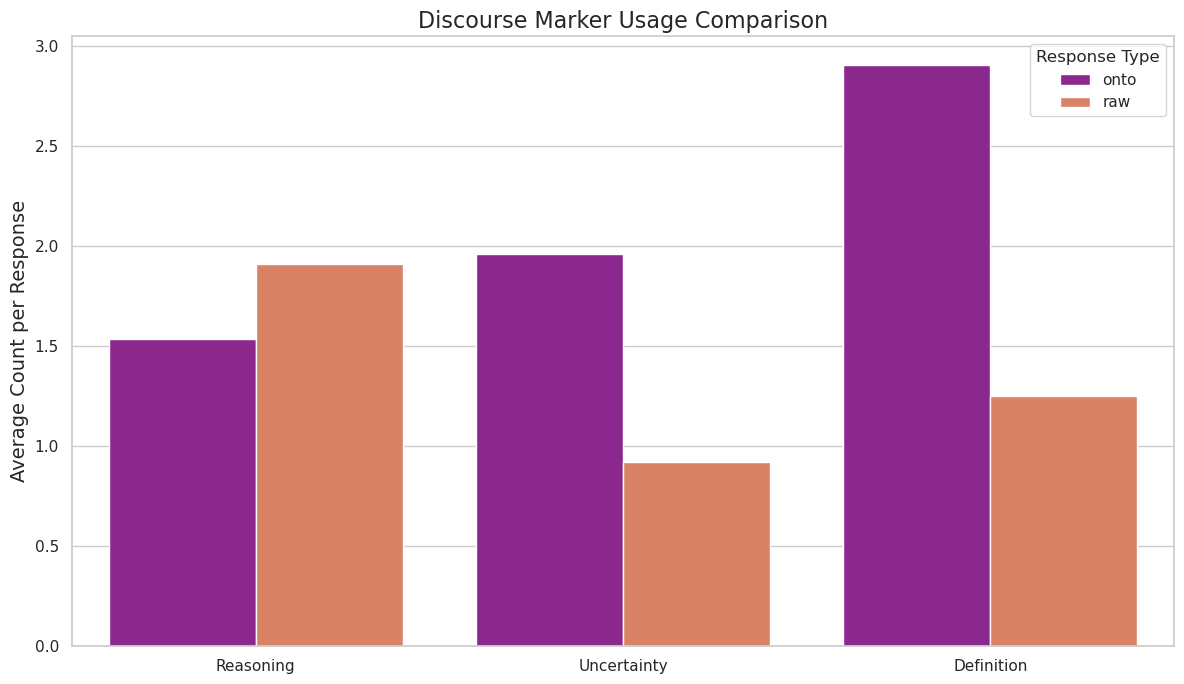

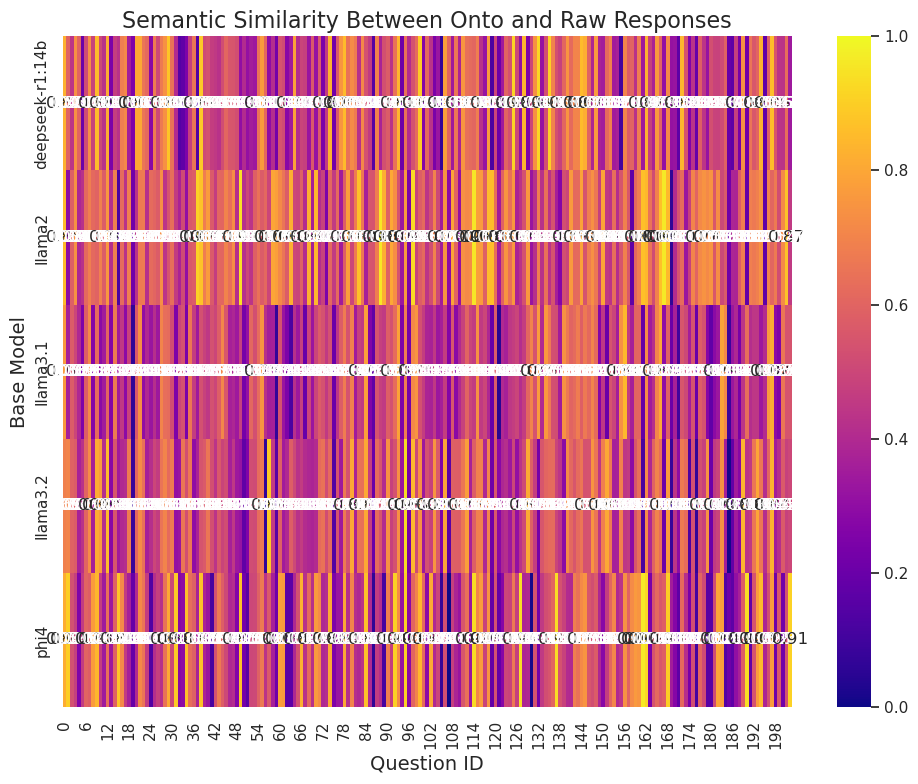

<Figure size 1400x700 with 0 Axes>

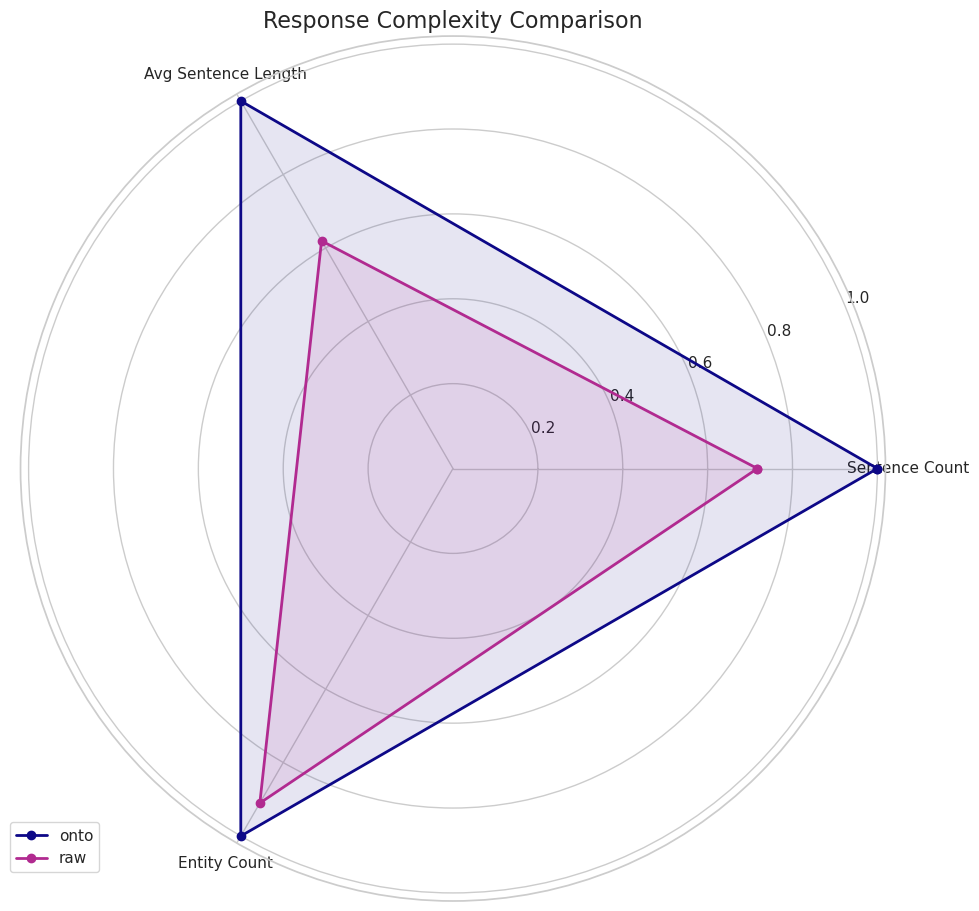

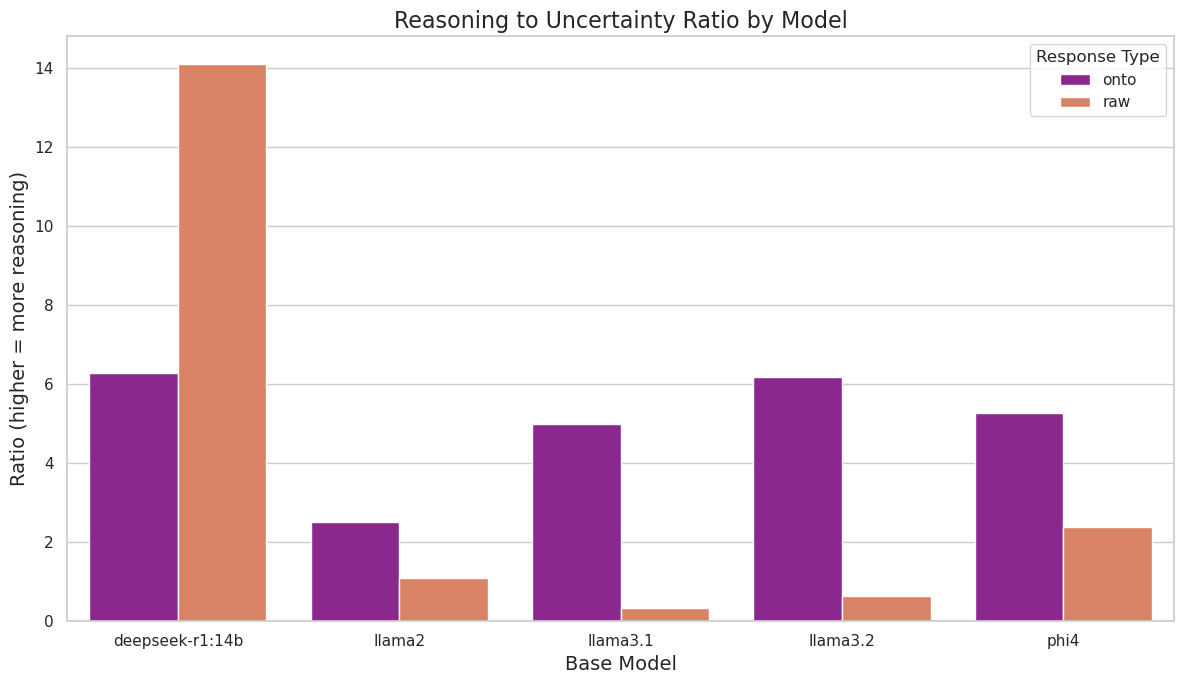

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualize_semantic_analysis(results_file='semantic_analysis_results_.csv', 
                               similarity_file='semantic_similarity_results.csv'):
    # Set the aesthetic style
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': 12})
    
    # Use plasma color palette
    plasma_colors = plt.cm.plasma(np.linspace(0, 0.8, 3))
    sns.set_palette(plasma_colors)
    
    # Load the data
    results_df = pd.read_csv(results_file)
    similarity_df = pd.read_csv(similarity_file)
    
    # 1. Create discourse marker comparison visualization
    plt.figure(figsize=(12, 7))
    
    # Prepare data for grouped bar chart
    marker_data = results_df.groupby('response_type')[
        ['reasoning_marker_count', 'uncertainty_marker_count', 'definition_marker_count']
    ].mean().reset_index()
    
    # Reshape for plotting
    marker_data_melted = pd.melt(
        marker_data, 
        id_vars=['response_type'],
        value_vars=['reasoning_marker_count', 'uncertainty_marker_count', 'definition_marker_count'],
        var_name='Marker Type', 
        value_name='Average Count'
    )
    
    # Create the grouped bar chart
    ax = sns.barplot(
        x='Marker Type', 
        y='Average Count', 
        hue='response_type',
        data=marker_data_melted,
        palette='plasma'
    )
    
    # Improve readability
    ax.set_xticklabels([x.get_text().replace('_marker_count', '').title() for x in ax.get_xticklabels()])
    plt.title('Discourse Marker Usage Comparison', fontsize=16)
    plt.ylabel('Average Count per Response', fontsize=14)
    plt.xlabel('', fontsize=14)
    plt.legend(title='Response Type', title_fontsize=12)
    plt.tight_layout()
    plt.savefig('discourse_markers_comparison.png', dpi=300)
    
    # 2. Semantic similarity heatmap by model
    if 'base_model' in similarity_df.columns:
        plt.figure(figsize=(10, 8))
        
        # Pivot to create model vs. question heatmap
        if 'question_id' in similarity_df.columns:
            similarity_pivot = similarity_df.pivot_table(
                index='base_model',
                columns='question_id',
                values='semantic_similarity'
            )
            
            # Create heatmap
            sns.heatmap(
                similarity_pivot, 
                annot=True, 
                cmap='plasma',
                vmin=0, 
                vmax=1,
                fmt='.2f'
            )
            plt.title('Semantic Similarity Between Onto and Raw Responses', fontsize=16)
            plt.ylabel('Base Model', fontsize=14)
            plt.xlabel('Question ID', fontsize=14)
            plt.tight_layout()
            plt.savefig('semantic_similarity_heatmap.png', dpi=300)
    
    # 3. Response complexity comparison
    plt.figure(figsize=(14, 7))
    
    # Prepare data
    complexity_data = results_df.groupby('response_type')[
        ['sentence_count', 'avg_sentence_length', 'entity_count']
    ].mean()
    
    # Normalize for radar chart
    complexity_max = complexity_data.max()
    complexity_norm = complexity_data / complexity_max
    
    # Set up the radar chart
    categories = ['Sentence Count', 'Avg Sentence Length', 'Entity Count']
    N = len(categories)
    
    # Create angles for the radar chart
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop
    
    # Plot radar chart
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    # Add data for each response type
    for i, response_type in enumerate(complexity_norm.index):
        values = complexity_norm.loc[response_type].values.tolist()
        values += values[:1]  # Close the loop
        ax.plot(angles, values, 'o-', linewidth=2, label=response_type, color=plasma_colors[i])
        ax.fill(angles, values, alpha=0.1, color=plasma_colors[i])
    
    # Set category labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    
    # Add legend
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.title('Response Complexity Comparison', fontsize=16)
    plt.tight_layout()
    plt.savefig('complexity_radar.png', dpi=300)
    
    # 4. Model performance bar chart
    if 'base_model' in results_df.columns:
        plt.figure(figsize=(12, 7))
        
        # Calculate the ratio of reasoning markers to uncertainty markers by model and response type
        results_df['reasoning_to_uncertainty'] = results_df['reasoning_marker_count'] / (results_df['uncertainty_marker_count'] + 0.1)
        
        # Group by model and response type
        reasoning_ratio = results_df.groupby(['base_model', 'response_type'])['reasoning_to_uncertainty'].mean().reset_index()
        
        # Create grouped bar chart
        sns.barplot(
            x='base_model', 
            y='reasoning_to_uncertainty',
            hue='response_type',
            data=reasoning_ratio,
            palette='plasma'
        )
        
        plt.title('Reasoning to Uncertainty Ratio by Model', fontsize=16)
        plt.ylabel('Ratio (higher = more reasoning)', fontsize=14)
        plt.xlabel('Base Model', fontsize=14)
        plt.legend(title='Response Type')
        plt.tight_layout()
        plt.savefig('reasoning_ratio_by_model.png', dpi=300)
        
    print("Visualizations created successfully!")

if __name__ == "__main__":
    visualize_semantic_analysis()

/tmp/ipykernel_2233882/3949062831.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([x.get_text().replace('_marker_count', '').title() for x in ax.get_xticklabels()])
/tmp/ipykernel_2233882/3949062831.py:81: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  similarity_pivot = sorted_similarity_df.pivot_table(
/tmp/ipykernel_2233882/3949062831.py:156: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  reasoning_ratio = results_df.groupby(['base_model', 'response_type'])['reasoning_to_uncertainty'].mean().reset_index()
/tmp/ipykernel_2233882/3

Visualizations created successfully!


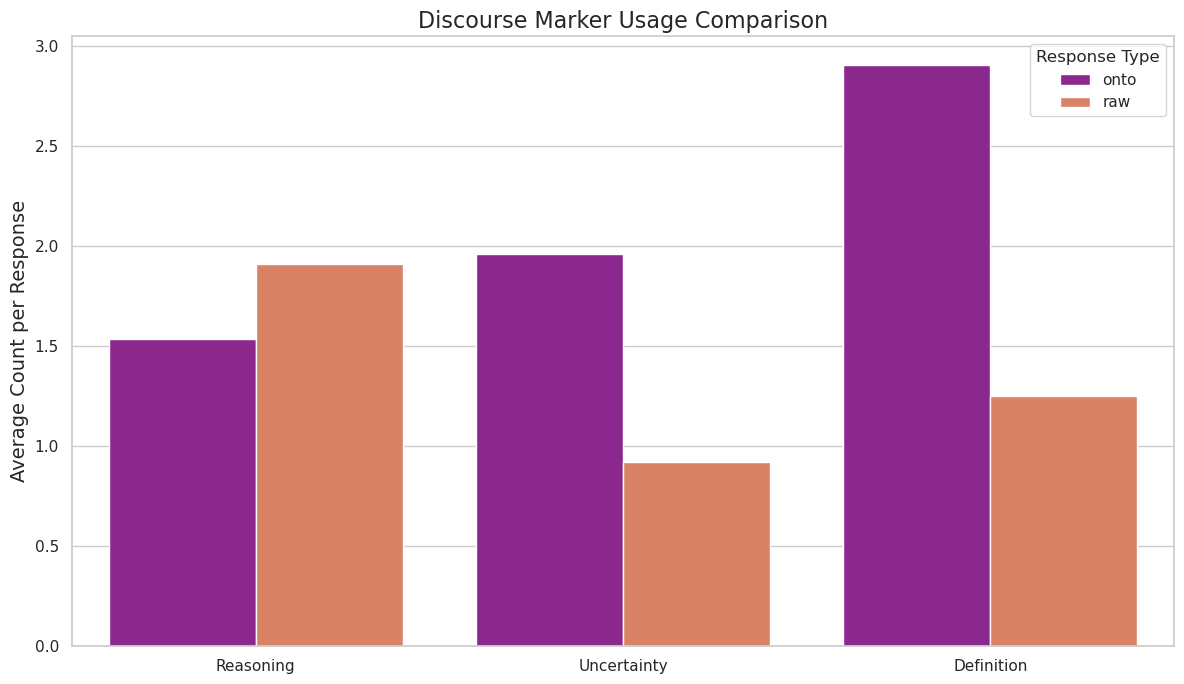

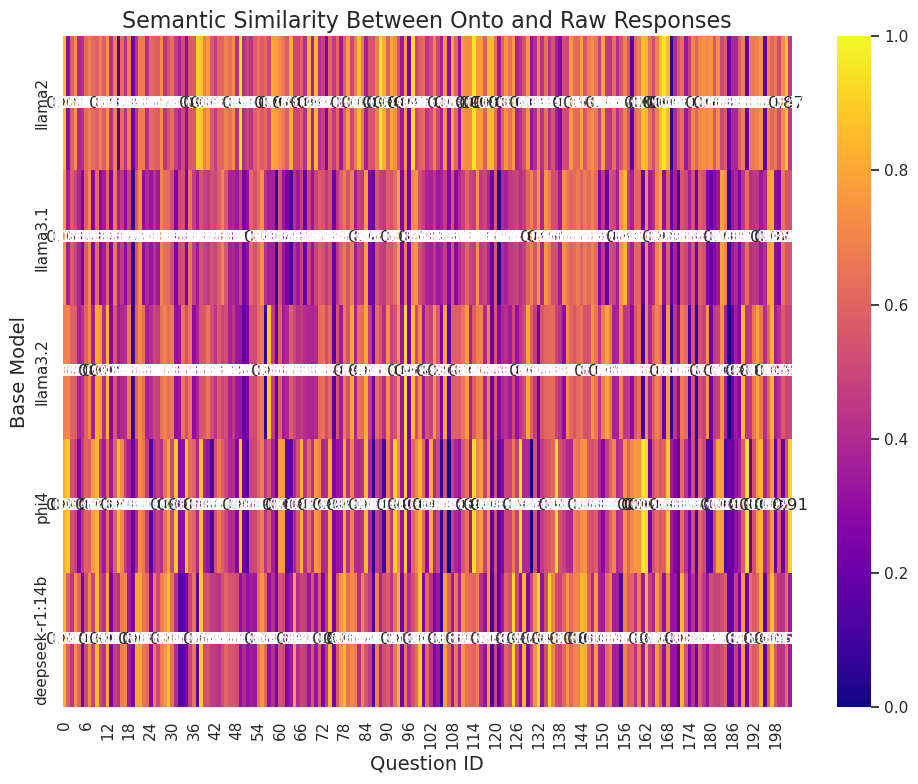

<Figure size 1400x700 with 0 Axes>

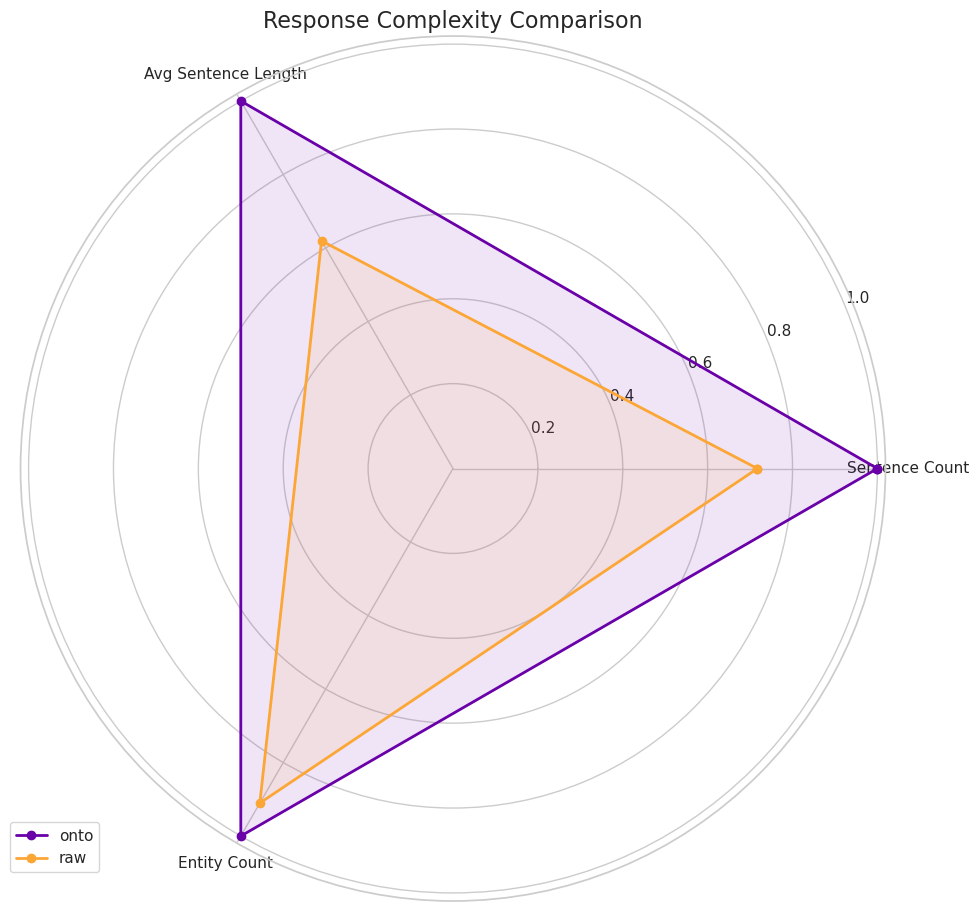

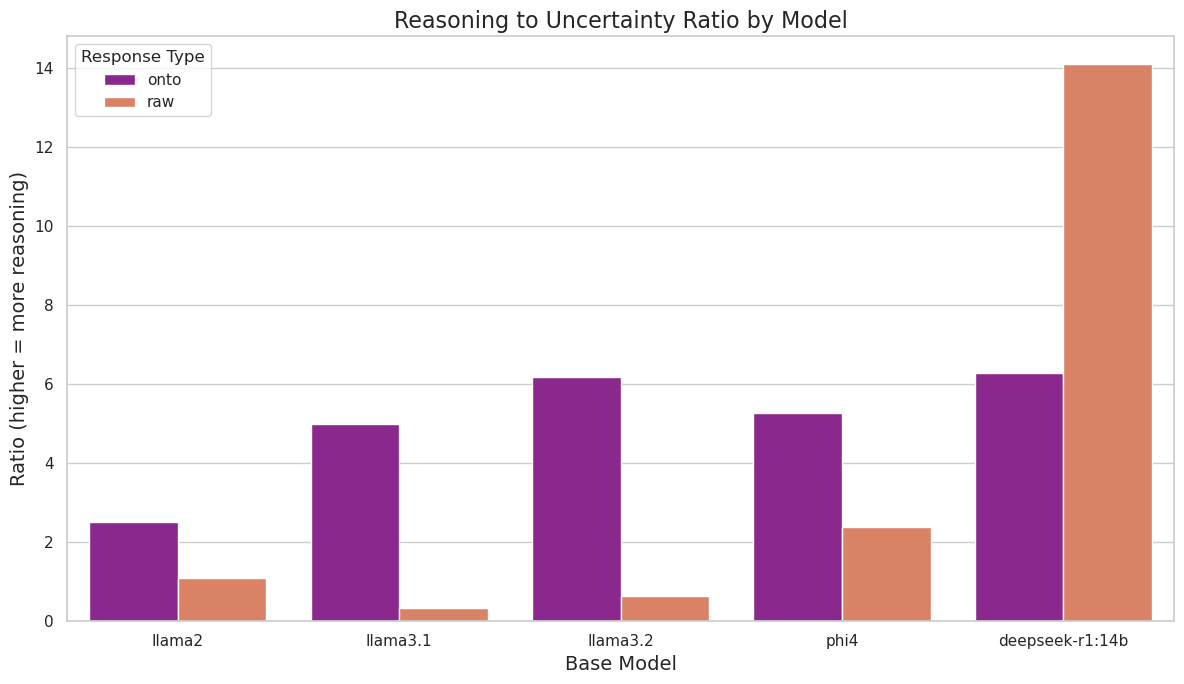

<Figure size 1400x800 with 0 Axes>

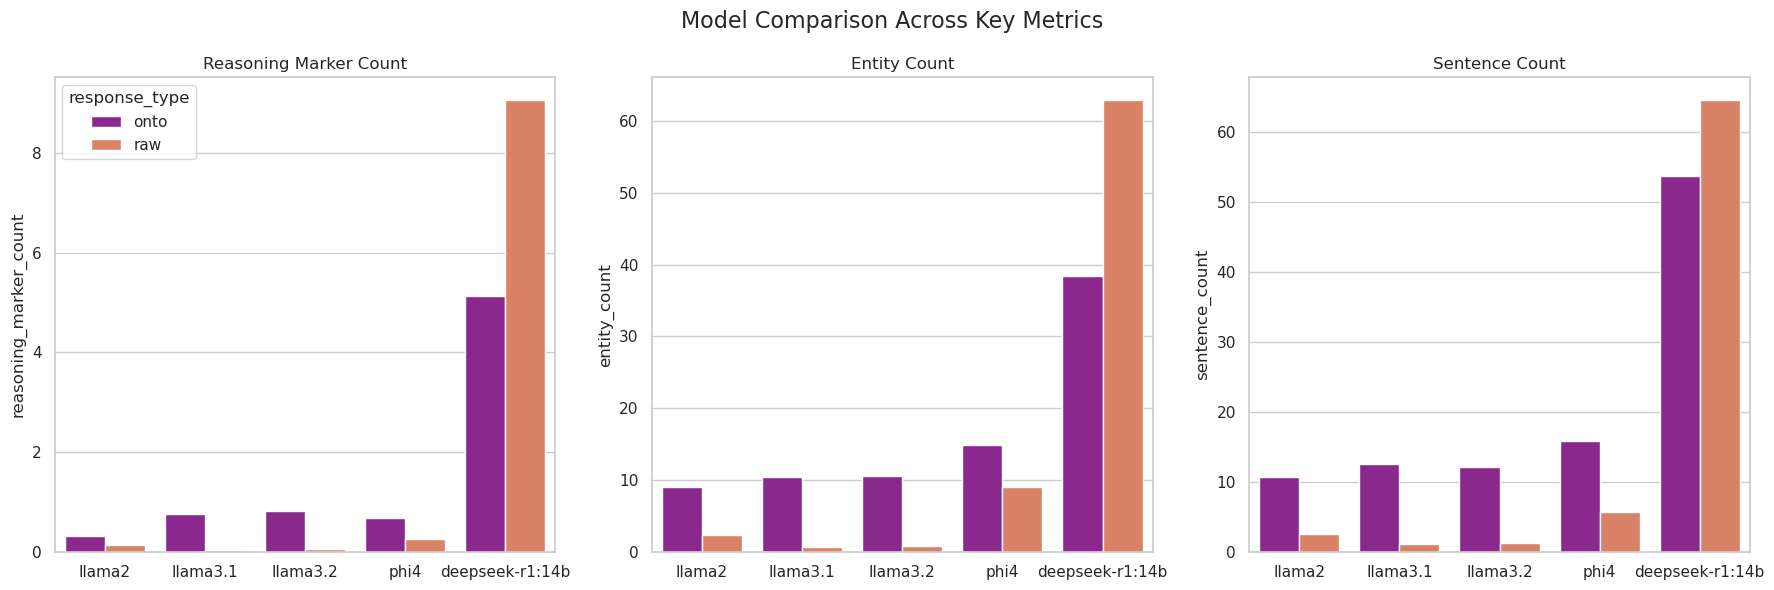

In [6]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualize_semantic_analysis(results_file='semantic_analysis_results.csv', 
                               similarity_file='semantic_similarity_results.csv'):
    # Set the aesthetic style
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': 12})
    
    # Use plasma color palette
    plasma_palette = 'plasma'
    
    # Load the data
    results_df = pd.read_csv(results_file)
    similarity_df = pd.read_csv(similarity_file)
    
    # Define the specific model order
    model_order = ['llama2', 'llama3.1', 'llama3.2', 'phi4', 'deepseek-r1:14b']
    
    # Ensure base_model column follows our order
    if 'base_model' in results_df.columns:
        results_df['base_model'] = pd.Categorical(
            results_df['base_model'], 
            categories=model_order, 
            ordered=True
        )
    
    if 'base_model' in similarity_df.columns:
        similarity_df['base_model'] = pd.Categorical(
            similarity_df['base_model'], 
            categories=model_order, 
            ordered=True
        )
    
    # 1. Create discourse marker comparison visualization
    plt.figure(figsize=(12, 7))
    
    # Prepare data for grouped bar chart
    marker_data = results_df.groupby('response_type')[
        ['reasoning_marker_count', 'uncertainty_marker_count', 'definition_marker_count']
    ].mean().reset_index()
    
    # Reshape for plotting
    marker_data_melted = pd.melt(
        marker_data, 
        id_vars=['response_type'],
        value_vars=['reasoning_marker_count', 'uncertainty_marker_count', 'definition_marker_count'],
        var_name='Marker Type', 
        value_name='Average Count'
    )
    
    # Create the grouped bar chart
    ax = sns.barplot(
        x='Marker Type', 
        y='Average Count', 
        hue='response_type',
        data=marker_data_melted,
        palette=plasma_palette
    )
    
    # Improve readability
    ax.set_xticklabels([x.get_text().replace('_marker_count', '').title() for x in ax.get_xticklabels()])
    plt.title('Discourse Marker Usage Comparison', fontsize=16)
    plt.ylabel('Average Count per Response', fontsize=14)
    plt.xlabel('', fontsize=14)
    plt.legend(title='Response Type', title_fontsize=12)
    plt.tight_layout()
    plt.savefig('discourse_markers_comparison.png', dpi=300)
    
    # 2. Semantic similarity heatmap by model
    if 'base_model' in similarity_df.columns:
        plt.figure(figsize=(10, 8))
        
        # Pivot to create model vs. question heatmap
        if 'question_id' in similarity_df.columns:
            # Sort by our model order
            sorted_similarity_df = similarity_df.sort_values('base_model')
            
            similarity_pivot = sorted_similarity_df.pivot_table(
                index='base_model',
                columns='question_id',
                values='semantic_similarity'
            )
            
            # Ensure models are in correct order
            similarity_pivot = similarity_pivot.reindex(model_order)
            
            # Create heatmap
            sns.heatmap(
                similarity_pivot, 
                annot=True, 
                cmap=plasma_palette,
                vmin=0, 
                vmax=1,
                fmt='.2f'
            )
            plt.title('Semantic Similarity Between Onto and Raw Responses', fontsize=16)
            plt.ylabel('Base Model', fontsize=14)
            plt.xlabel('Question ID', fontsize=14)
            plt.tight_layout()
            plt.savefig('semantic_similarity_heatmap.png', dpi=300)
    
    # 3. Response complexity comparison
    plt.figure(figsize=(14, 7))
    
    # Prepare data
    complexity_data = results_df.groupby('response_type')[
        ['sentence_count', 'avg_sentence_length', 'entity_count']
    ].mean()
    
    # Normalize for radar chart
    complexity_max = complexity_data.max()
    complexity_norm = complexity_data / complexity_max
    
    # Set up the radar chart
    categories = ['Sentence Count', 'Avg Sentence Length', 'Entity Count']
    N = len(categories)
    
    # Create angles for the radar chart
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop
    
    # Get plasma colors for the radar chart
    plasma_colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(complexity_norm.index)))
    
    # Plot radar chart
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    # Add data for each response type
    for i, response_type in enumerate(complexity_norm.index):
        values = complexity_norm.loc[response_type].values.tolist()
        values += values[:1]  # Close the loop
        ax.plot(angles, values, 'o-', linewidth=2, label=response_type, color=plasma_colors[i])
        ax.fill(angles, values, alpha=0.1, color=plasma_colors[i])
    
    # Set category labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    
    # Add legend
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.title('Response Complexity Comparison', fontsize=16)
    plt.tight_layout()
    plt.savefig('complexity_radar.png', dpi=300)
    
    # 4. Model performance bar chart
    if 'base_model' in results_df.columns:
        plt.figure(figsize=(12, 7))
        
        # Calculate the ratio of reasoning markers to uncertainty markers by model and response type
        results_df['reasoning_to_uncertainty'] = results_df['reasoning_marker_count'] / (results_df['uncertainty_marker_count'] + 0.1)
        
        # Group by model and response type
        reasoning_ratio = results_df.groupby(['base_model', 'response_type'])['reasoning_to_uncertainty'].mean().reset_index()
        
        # Sort by our specified model order
        reasoning_ratio = reasoning_ratio.sort_values('base_model')
        
        # Create grouped bar chart
        sns.barplot(
            x='base_model', 
            y='reasoning_to_uncertainty',
            hue='response_type',
            data=reasoning_ratio,
            palette=plasma_palette,
            order=model_order
        )
        
        plt.title('Reasoning to Uncertainty Ratio by Model', fontsize=16)
        plt.ylabel('Ratio (higher = more reasoning)', fontsize=14)
        plt.xlabel('Base Model', fontsize=14)
        plt.legend(title='Response Type')
        plt.tight_layout()
        plt.savefig('reasoning_ratio_by_model.png', dpi=300)
        
    # 5. Add a new visualization: Model comparison across all metrics
    if 'base_model' in results_df.columns:
        plt.figure(figsize=(14, 8))
        
        # Calculate aggregated metrics by model and response type
        model_metrics = results_df.groupby(['base_model', 'response_type']).agg({
            'reasoning_marker_count': 'mean',
            'entity_count': 'mean',
            'sentence_count': 'mean'
        }).reset_index()
        
        # Create facet grid for the three metrics
        metrics = ['reasoning_marker_count', 'entity_count', 'sentence_count']
        fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
        
        # Plot each metric
        for i, metric in enumerate(metrics):
            sns.barplot(
                x='base_model', 
                y=metric,
                hue='response_type',
                data=model_metrics,
                palette=plasma_palette,
                order=model_order,
                ax=axes[i]
            )
            axes[i].set_title(metric.replace('_', ' ').title())
            axes[i].set_xlabel('')
            if i > 0:
                axes[i].get_legend().remove()
            
        plt.suptitle('Model Comparison Across Key Metrics', fontsize=16)
        plt.tight_layout()
        plt.savefig('model_metrics_comparison.png', dpi=300)
        
    print("Visualizations created successfully!")

if __name__ == "__main__":
    visualize_semantic_analysis()

/tmp/ipykernel_2233882/3154922849.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([x.get_text().replace('_marker_count', '').title() for x in ax.get_xticklabels()])
/tmp/ipykernel_2233882/3154922849.py:81: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  similarity_pivot = sorted_similarity_df.pivot_table(
/tmp/ipykernel_2233882/3154922849.py:156: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  reasoning_ratio = results_df.groupby(['base_model', 'response_type'])['reasoning_to_uncertainty'].mean().reset_index()
/tmp/ipykernel_2233882/3

Visualizations created successfully!


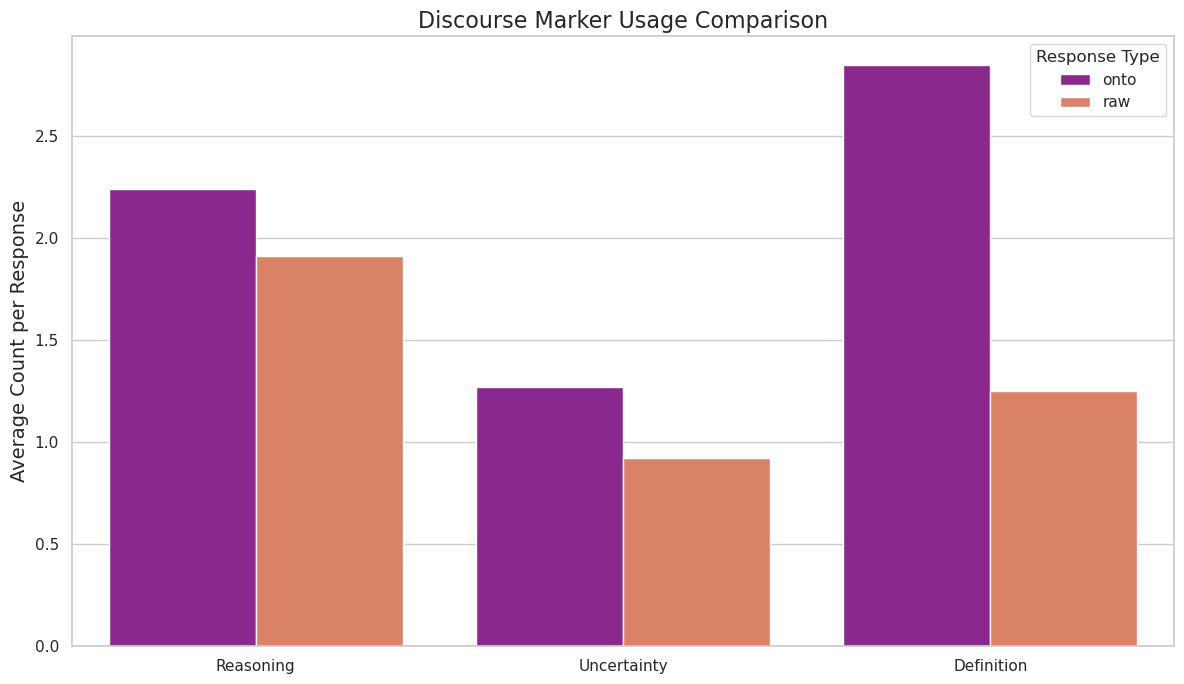

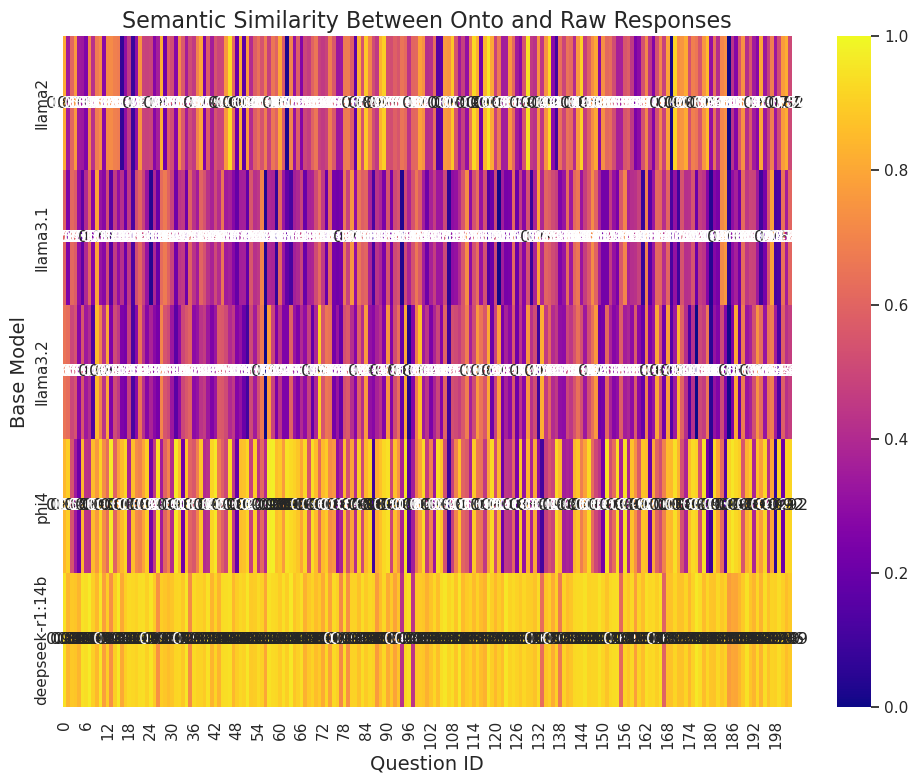

<Figure size 1400x700 with 0 Axes>

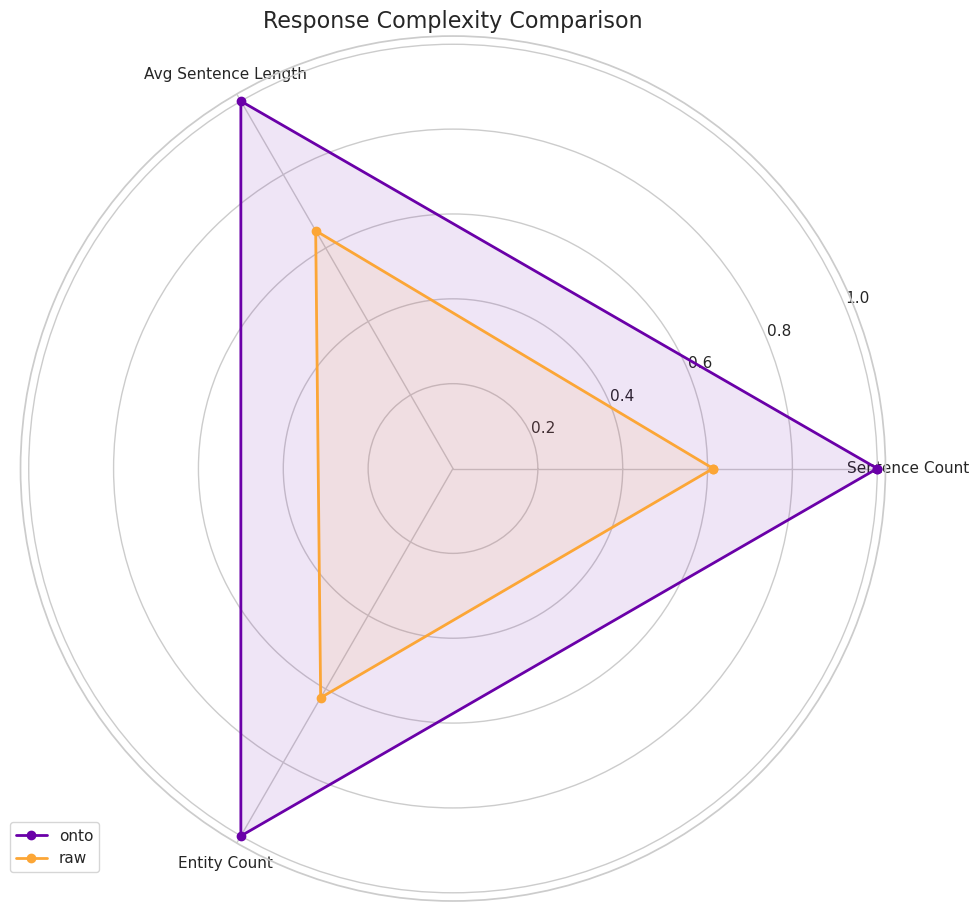

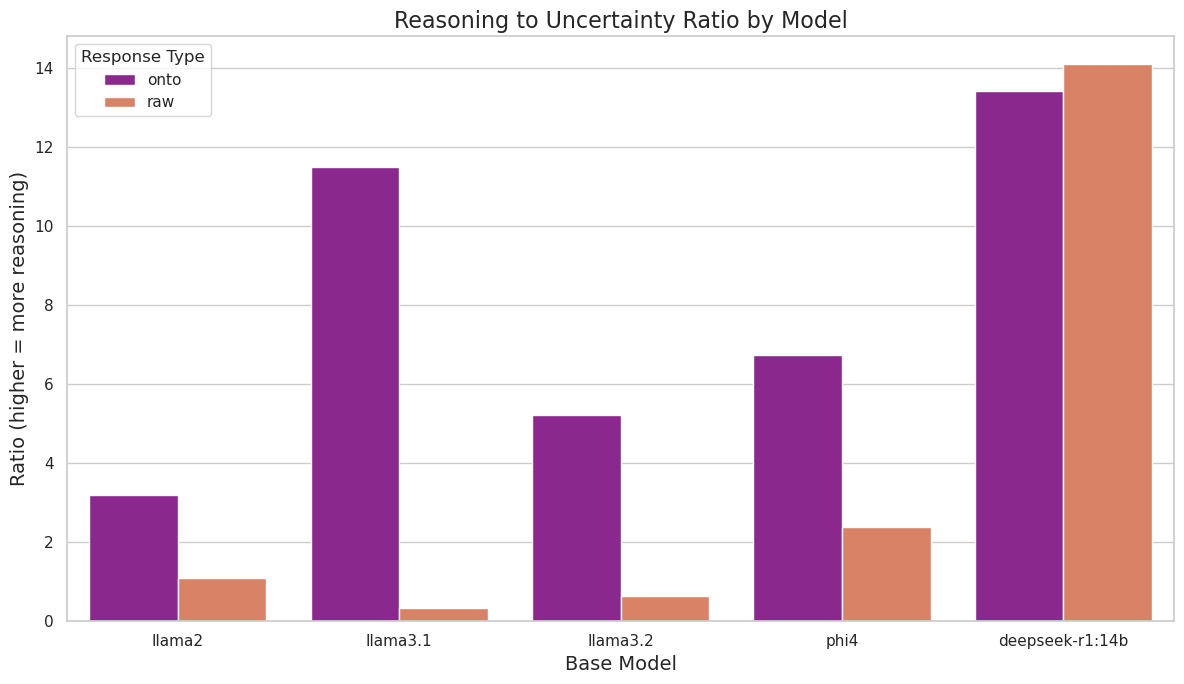

<Figure size 1400x800 with 0 Axes>

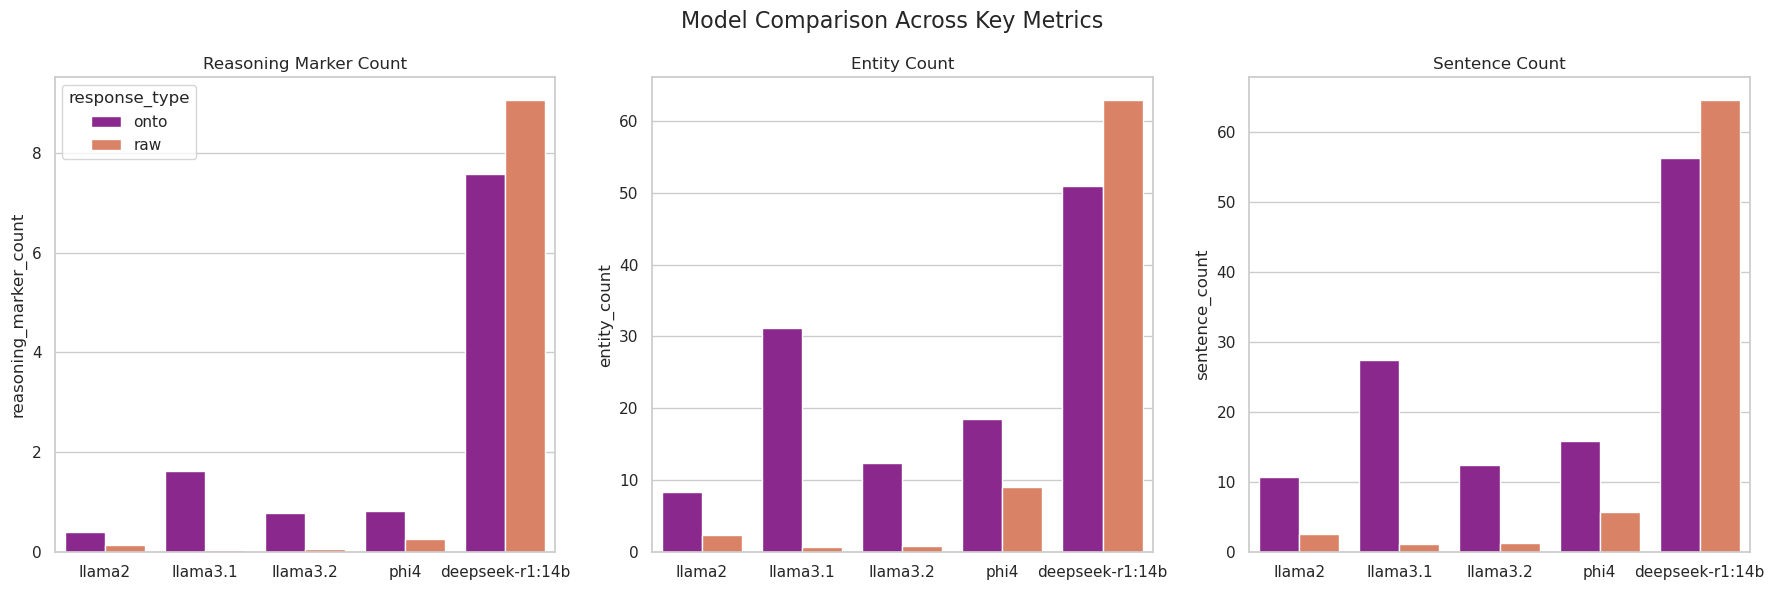

In [8]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualize_semantic_analysis(results_file='semantic_analysis_results_Question.csv', 
                               similarity_file='semantic_similarity_results_Question.csv'):
    # Set the aesthetic style
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': 12})
    
    # Use plasma color palette
    plasma_palette = 'plasma'
    
    # Load the data
    results_df = pd.read_csv(results_file)
    similarity_df = pd.read_csv(similarity_file)
    
    # Define the specific model order
    model_order = ['llama2', 'llama3.1', 'llama3.2', 'phi4', 'deepseek-r1:14b']
    
    # Ensure base_model column follows our order
    if 'base_model' in results_df.columns:
        results_df['base_model'] = pd.Categorical(
            results_df['base_model'], 
            categories=model_order, 
            ordered=True
        )
    
    if 'base_model' in similarity_df.columns:
        similarity_df['base_model'] = pd.Categorical(
            similarity_df['base_model'], 
            categories=model_order, 
            ordered=True
        )
    
    # 1. Create discourse marker comparison visualization
    plt.figure(figsize=(12, 7))
    
    # Prepare data for grouped bar chart
    marker_data = results_df.groupby('response_type')[
        ['reasoning_marker_count', 'uncertainty_marker_count', 'definition_marker_count']
    ].mean().reset_index()
    
    # Reshape for plotting
    marker_data_melted = pd.melt(
        marker_data, 
        id_vars=['response_type'],
        value_vars=['reasoning_marker_count', 'uncertainty_marker_count', 'definition_marker_count'],
        var_name='Marker Type', 
        value_name='Average Count'
    )
    
    # Create the grouped bar chart
    ax = sns.barplot(
        x='Marker Type', 
        y='Average Count', 
        hue='response_type',
        data=marker_data_melted,
        palette=plasma_palette
    )
    
    # Improve readability
    ax.set_xticklabels([x.get_text().replace('_marker_count', '').title() for x in ax.get_xticklabels()])
    plt.title('Discourse Marker Usage Comparison', fontsize=16)
    plt.ylabel('Average Count per Response', fontsize=14)
    plt.xlabel('', fontsize=14)
    plt.legend(title='Response Type', title_fontsize=12)
    plt.tight_layout()
    plt.savefig('discourse_markers_comparison.png', dpi=300)
    
    # 2. Semantic similarity heatmap by model
    if 'base_model' in similarity_df.columns:
        plt.figure(figsize=(10, 8))
        
        # Pivot to create model vs. question heatmap
        if 'question_id' in similarity_df.columns:
            # Sort by our model order
            sorted_similarity_df = similarity_df.sort_values('base_model')
            
            similarity_pivot = sorted_similarity_df.pivot_table(
                index='base_model',
                columns='question_id',
                values='semantic_similarity'
            )
            
            # Ensure models are in correct order
            similarity_pivot = similarity_pivot.reindex(model_order)
            
            # Create heatmap
            sns.heatmap(
                similarity_pivot, 
                annot=True, 
                cmap=plasma_palette,
                vmin=0, 
                vmax=1,
                fmt='.2f'
            )
            plt.title('Semantic Similarity Between Onto and Raw Responses', fontsize=16)
            plt.ylabel('Base Model', fontsize=14)
            plt.xlabel('Question ID', fontsize=14)
            plt.tight_layout()
            plt.savefig('semantic_similarity_heatmap.png', dpi=300)
    
    # 3. Response complexity comparison
    plt.figure(figsize=(14, 7))
    
    # Prepare data
    complexity_data = results_df.groupby('response_type')[
        ['sentence_count', 'avg_sentence_length', 'entity_count']
    ].mean()
    
    # Normalize for radar chart
    complexity_max = complexity_data.max()
    complexity_norm = complexity_data / complexity_max
    
    # Set up the radar chart
    categories = ['Sentence Count', 'Avg Sentence Length', 'Entity Count']
    N = len(categories)
    
    # Create angles for the radar chart
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop
    
    # Get plasma colors for the radar chart
    plasma_colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(complexity_norm.index)))
    
    # Plot radar chart
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    # Add data for each response type
    for i, response_type in enumerate(complexity_norm.index):
        values = complexity_norm.loc[response_type].values.tolist()
        values += values[:1]  # Close the loop
        ax.plot(angles, values, 'o-', linewidth=2, label=response_type, color=plasma_colors[i])
        ax.fill(angles, values, alpha=0.1, color=plasma_colors[i])
    
    # Set category labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    
    # Add legend
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.title('Response Complexity Comparison', fontsize=16)
    plt.tight_layout()
    plt.savefig('complexity_radar.png', dpi=300)
    
    # 4. Model performance bar chart
    if 'base_model' in results_df.columns:
        plt.figure(figsize=(12, 7))
        
        # Calculate the ratio of reasoning markers to uncertainty markers by model and response type
        results_df['reasoning_to_uncertainty'] = results_df['reasoning_marker_count'] / (results_df['uncertainty_marker_count'] + 0.1)
        
        # Group by model and response type
        reasoning_ratio = results_df.groupby(['base_model', 'response_type'])['reasoning_to_uncertainty'].mean().reset_index()
        
        # Sort by our specified model order
        reasoning_ratio = reasoning_ratio.sort_values('base_model')
        
        # Create grouped bar chart
        sns.barplot(
            x='base_model', 
            y='reasoning_to_uncertainty',
            hue='response_type',
            data=reasoning_ratio,
            palette=plasma_palette,
            order=model_order
        )
        
        plt.title('Reasoning to Uncertainty Ratio by Model', fontsize=16)
        plt.ylabel('Ratio (higher = more reasoning)', fontsize=14)
        plt.xlabel('Base Model', fontsize=14)
        plt.legend(title='Response Type')
        plt.tight_layout()
        plt.savefig('reasoning_ratio_by_model.png', dpi=300)
        
    # 5. Add a new visualization: Model comparison across all metrics
    if 'base_model' in results_df.columns:
        plt.figure(figsize=(14, 8))
        
        # Calculate aggregated metrics by model and response type
        model_metrics = results_df.groupby(['base_model', 'response_type']).agg({
            'reasoning_marker_count': 'mean',
            'entity_count': 'mean',
            'sentence_count': 'mean'
        }).reset_index()
        
        # Create facet grid for the three metrics
        metrics = ['reasoning_marker_count', 'entity_count', 'sentence_count']
        fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
        
        # Plot each metric
        for i, metric in enumerate(metrics):
            sns.barplot(
                x='base_model', 
                y=metric,
                hue='response_type',
                data=model_metrics,
                palette=plasma_palette,
                order=model_order,
                ax=axes[i]
            )
            axes[i].set_title(metric.replace('_', ' ').title())
            axes[i].set_xlabel('')
            if i > 0:
                axes[i].get_legend().remove()
            
        plt.suptitle('Model Comparison Across Key Metrics', fontsize=16)
        plt.tight_layout()
        plt.savefig('model_metrics_comparison.png', dpi=300)
        
    print("Visualizations created successfully!")

if __name__ == "__main__":
    visualize_semantic_analysis()

/tmp/ipykernel_2233882/3942456694.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([x.get_text().replace('_marker_count', '').title() for x in ax.get_xticklabels()])
/tmp/ipykernel_2233882/3942456694.py:81: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  similarity_pivot = sorted_similarity_df.pivot_table(
/tmp/ipykernel_2233882/3942456694.py:156: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  reasoning_ratio = results_df.groupby(['base_model', 'response_type'])['reasoning_to_uncertainty'].mean().reset_index()
/tmp/ipykernel_2233882/3

Visualizations created successfully!


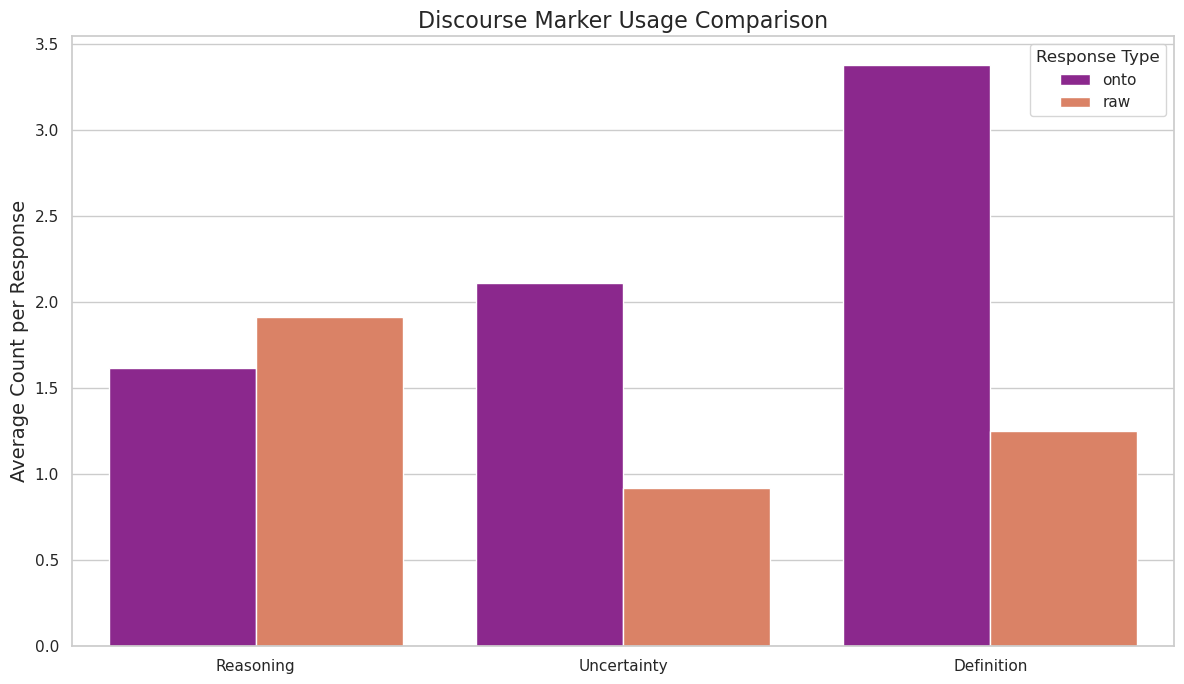

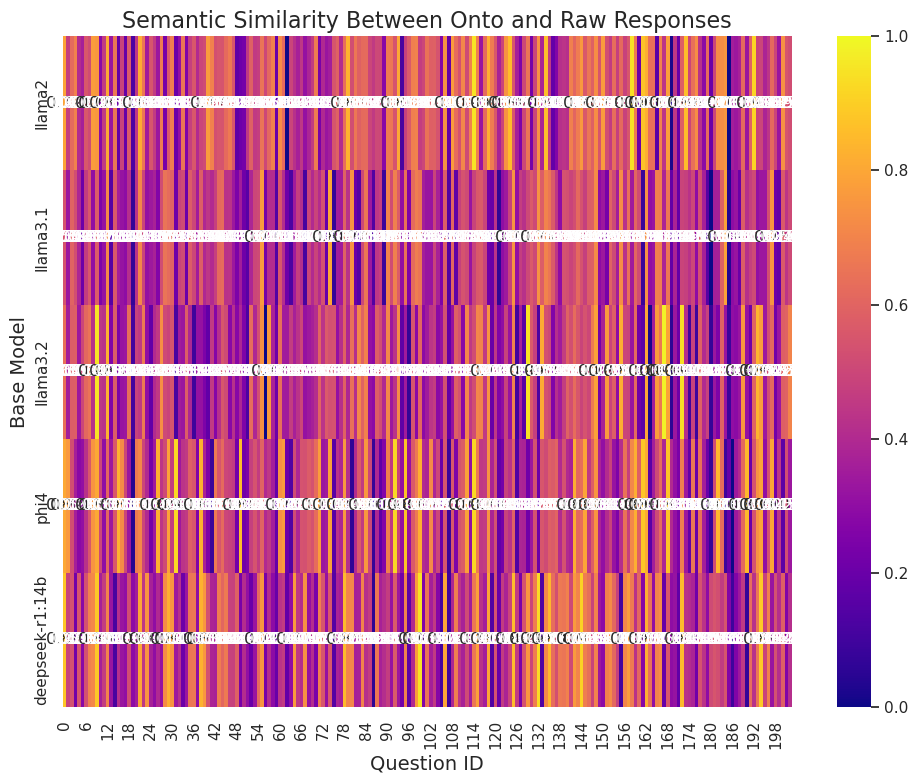

<Figure size 1400x700 with 0 Axes>

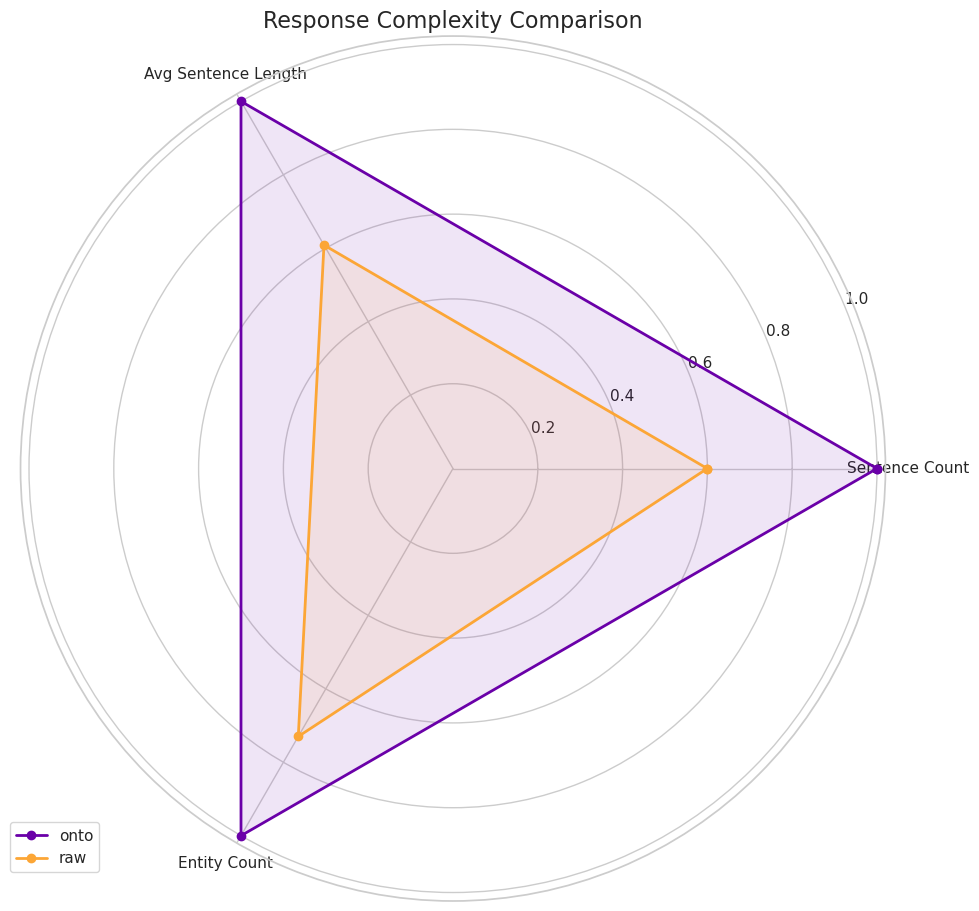

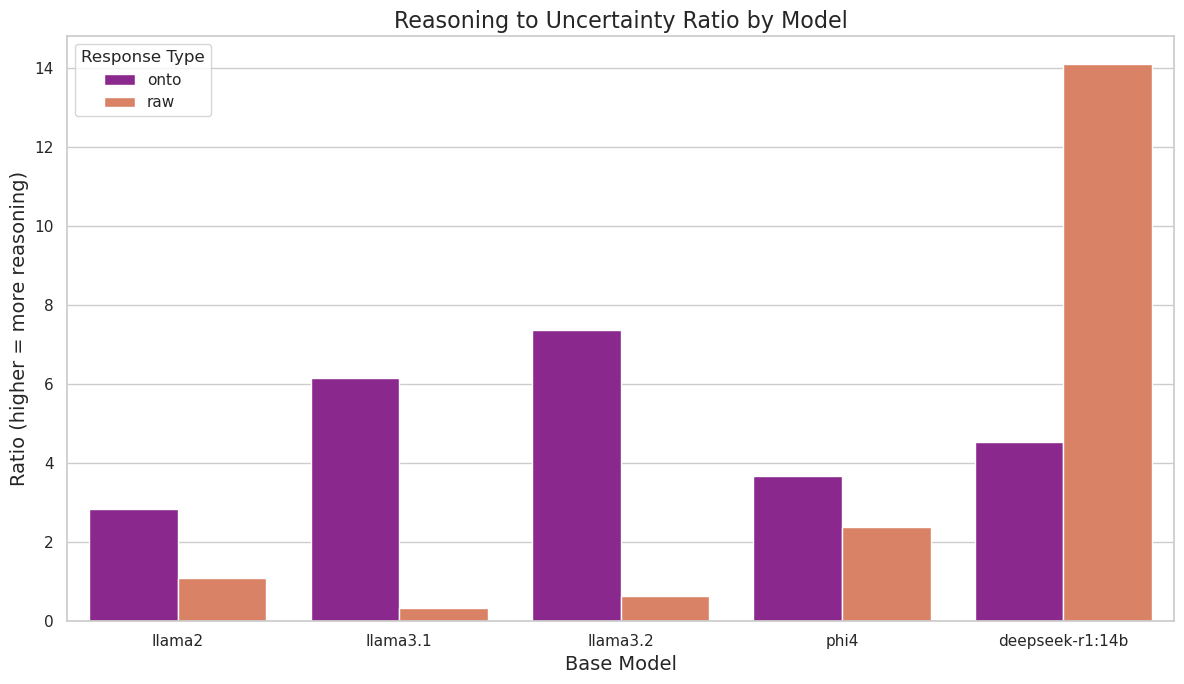

<Figure size 1400x800 with 0 Axes>

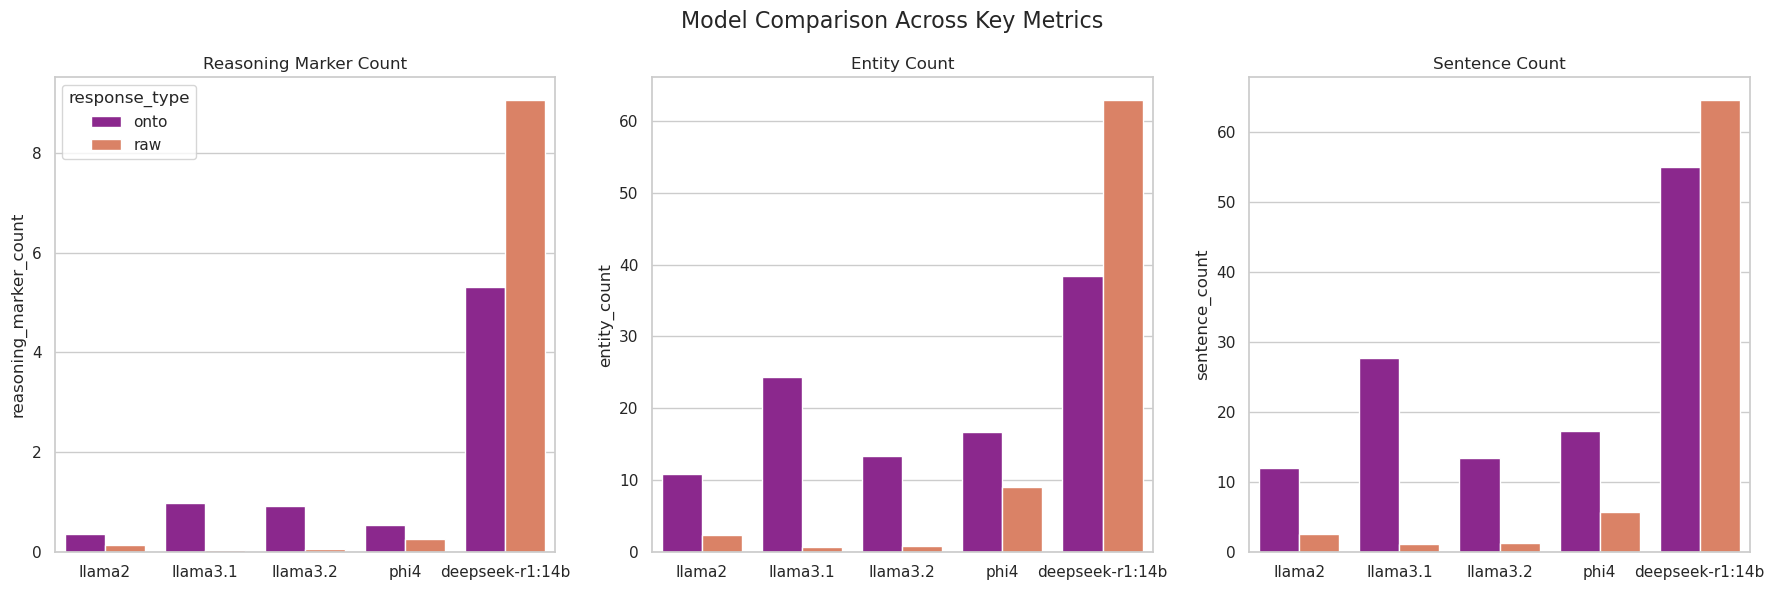

In [10]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualize_semantic_analysis(results_file='/home/matt/Proj/Hermeticav2/scripts/semantic_analysis_results_Dual.csv', 
                               similarity_file='/home/matt/Proj/Hermeticav2/scripts/semantic_similarity_results_Dual.csv'):
    # Set the aesthetic style
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': 12})
    
    # Use plasma color palette
    plasma_palette = 'plasma'
    
    # Load the data
    results_df = pd.read_csv(results_file)
    similarity_df = pd.read_csv(similarity_file)
    
    # Define the specific model order
    model_order = ['llama2', 'llama3.1', 'llama3.2', 'phi4', 'deepseek-r1:14b']
    
    # Ensure base_model column follows our order
    if 'base_model' in results_df.columns:
        results_df['base_model'] = pd.Categorical(
            results_df['base_model'], 
            categories=model_order, 
            ordered=True
        )
    
    if 'base_model' in similarity_df.columns:
        similarity_df['base_model'] = pd.Categorical(
            similarity_df['base_model'], 
            categories=model_order, 
            ordered=True
        )
    
    # 1. Create discourse marker comparison visualization
    plt.figure(figsize=(12, 7))
    
    # Prepare data for grouped bar chart
    marker_data = results_df.groupby('response_type')[
        ['reasoning_marker_count', 'uncertainty_marker_count', 'definition_marker_count']
    ].mean().reset_index()
    
    # Reshape for plotting
    marker_data_melted = pd.melt(
        marker_data, 
        id_vars=['response_type'],
        value_vars=['reasoning_marker_count', 'uncertainty_marker_count', 'definition_marker_count'],
        var_name='Marker Type', 
        value_name='Average Count'
    )
    
    # Create the grouped bar chart
    ax = sns.barplot(
        x='Marker Type', 
        y='Average Count', 
        hue='response_type',
        data=marker_data_melted,
        palette=plasma_palette
    )
    
    # Improve readability
    ax.set_xticklabels([x.get_text().replace('_marker_count', '').title() for x in ax.get_xticklabels()])
    plt.title('Discourse Marker Usage Comparison', fontsize=16)
    plt.ylabel('Average Count per Response', fontsize=14)
    plt.xlabel('', fontsize=14)
    plt.legend(title='Response Type', title_fontsize=12)
    plt.tight_layout()
    plt.savefig('discourse_markers_comparison.png', dpi=300)
    
    # 2. Semantic similarity heatmap by model
    if 'base_model' in similarity_df.columns:
        plt.figure(figsize=(10, 8))
        
        # Pivot to create model vs. question heatmap
        if 'question_id' in similarity_df.columns:
            # Sort by our model order
            sorted_similarity_df = similarity_df.sort_values('base_model')
            
            similarity_pivot = sorted_similarity_df.pivot_table(
                index='base_model',
                columns='question_id',
                values='semantic_similarity'
            )
            
            # Ensure models are in correct order
            similarity_pivot = similarity_pivot.reindex(model_order)
            
            # Create heatmap
            sns.heatmap(
                similarity_pivot, 
                annot=True, 
                cmap=plasma_palette,
                vmin=0, 
                vmax=1,
                fmt='.2f'
            )
            plt.title('Semantic Similarity Between Onto and Raw Responses', fontsize=16)
            plt.ylabel('Base Model', fontsize=14)
            plt.xlabel('Question ID', fontsize=14)
            plt.tight_layout()
            plt.savefig('semantic_similarity_heatmap.png', dpi=300)
    
    # 3. Response complexity comparison
    plt.figure(figsize=(14, 7))
    
    # Prepare data
    complexity_data = results_df.groupby('response_type')[
        ['sentence_count', 'avg_sentence_length', 'entity_count']
    ].mean()
    
    # Normalize for radar chart
    complexity_max = complexity_data.max()
    complexity_norm = complexity_data / complexity_max
    
    # Set up the radar chart
    categories = ['Sentence Count', 'Avg Sentence Length', 'Entity Count']
    N = len(categories)
    
    # Create angles for the radar chart
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop
    
    # Get plasma colors for the radar chart
    plasma_colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(complexity_norm.index)))
    
    # Plot radar chart
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    # Add data for each response type
    for i, response_type in enumerate(complexity_norm.index):
        values = complexity_norm.loc[response_type].values.tolist()
        values += values[:1]  # Close the loop
        ax.plot(angles, values, 'o-', linewidth=2, label=response_type, color=plasma_colors[i])
        ax.fill(angles, values, alpha=0.1, color=plasma_colors[i])
    
    # Set category labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    
    # Add legend
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.title('Response Complexity Comparison', fontsize=16)
    plt.tight_layout()
    plt.savefig('complexity_radar.png', dpi=300)
    
    # 4. Model performance bar chart
    if 'base_model' in results_df.columns:
        plt.figure(figsize=(12, 7))
        
        # Calculate the ratio of reasoning markers to uncertainty markers by model and response type
        results_df['reasoning_to_uncertainty'] = results_df['reasoning_marker_count'] / (results_df['uncertainty_marker_count'] + 0.1)
        
        # Group by model and response type
        reasoning_ratio = results_df.groupby(['base_model', 'response_type'])['reasoning_to_uncertainty'].mean().reset_index()
        
        # Sort by our specified model order
        reasoning_ratio = reasoning_ratio.sort_values('base_model')
        
        # Create grouped bar chart
        sns.barplot(
            x='base_model', 
            y='reasoning_to_uncertainty',
            hue='response_type',
            data=reasoning_ratio,
            palette=plasma_palette,
            order=model_order
        )
        
        plt.title('Reasoning to Uncertainty Ratio by Model', fontsize=16)
        plt.ylabel('Ratio (higher = more reasoning)', fontsize=14)
        plt.xlabel('Base Model', fontsize=14)
        plt.legend(title='Response Type')
        plt.tight_layout()
        plt.savefig('reasoning_ratio_by_model.png', dpi=300)
        
    # 5. Add a new visualization: Model comparison across all metrics
    if 'base_model' in results_df.columns:
        plt.figure(figsize=(14, 8))
        
        # Calculate aggregated metrics by model and response type
        model_metrics = results_df.groupby(['base_model', 'response_type']).agg({
            'reasoning_marker_count': 'mean',
            'entity_count': 'mean',
            'sentence_count': 'mean'
        }).reset_index()
        
        # Create facet grid for the three metrics
        metrics = ['reasoning_marker_count', 'entity_count', 'sentence_count']
        fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
        
        # Plot each metric
        for i, metric in enumerate(metrics):
            sns.barplot(
                x='base_model', 
                y=metric,
                hue='response_type',
                data=model_metrics,
                palette=plasma_palette,
                order=model_order,
                ax=axes[i]
            )
            axes[i].set_title(metric.replace('_', ' ').title())
            axes[i].set_xlabel('')
            if i > 0:
                axes[i].get_legend().remove()
            
        plt.suptitle('Model Comparison Across Key Metrics', fontsize=16)
        plt.tight_layout()
        plt.savefig('model_metrics_comparison.png', dpi=300)
        
    print("Visualizations created successfully!")

if __name__ == "__main__":
    visualize_semantic_analysis()

/tmp/ipykernel_2233882/563523830.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([x.get_text().replace('_marker_count', '').title() for x in ax.get_xticklabels()])
/tmp/ipykernel_2233882/563523830.py:81: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  similarity_pivot = sorted_similarity_df.pivot_table(
/tmp/ipykernel_2233882/563523830.py:161: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  reasoning_ratio = results_df.groupby(['base_model', 'response_type'])['reasoning_to_uncertainty'].mean().reset_index()
/tmp/ipykernel_2233882/5635

Visualizations created successfully!


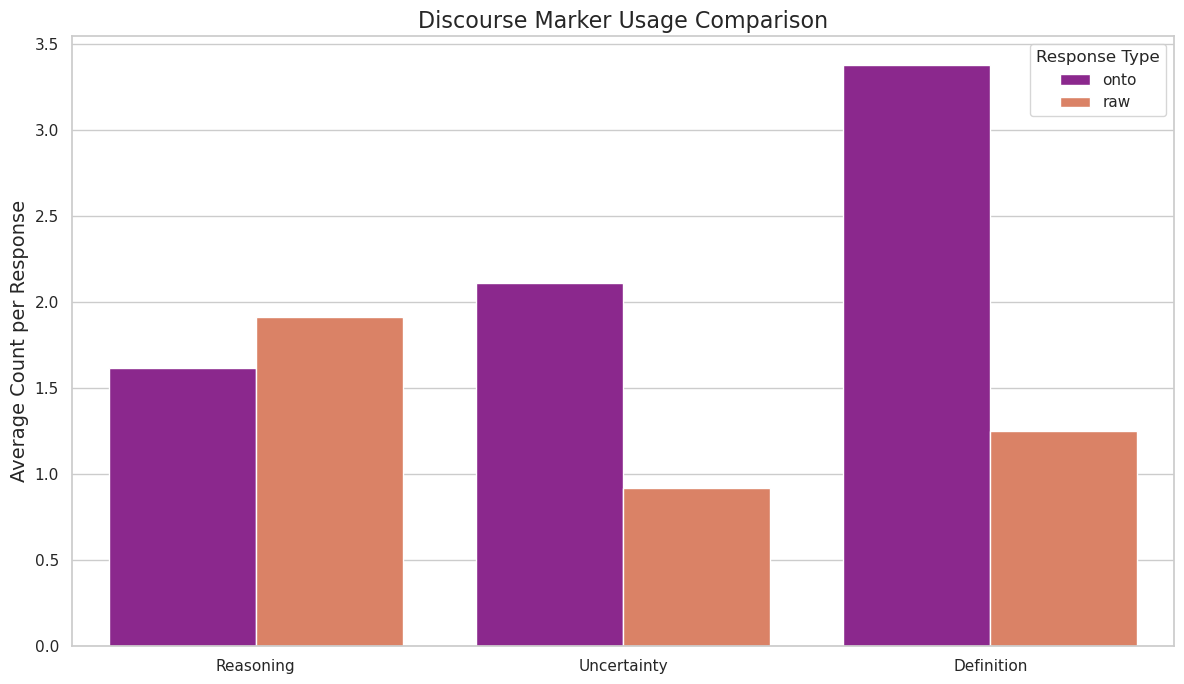

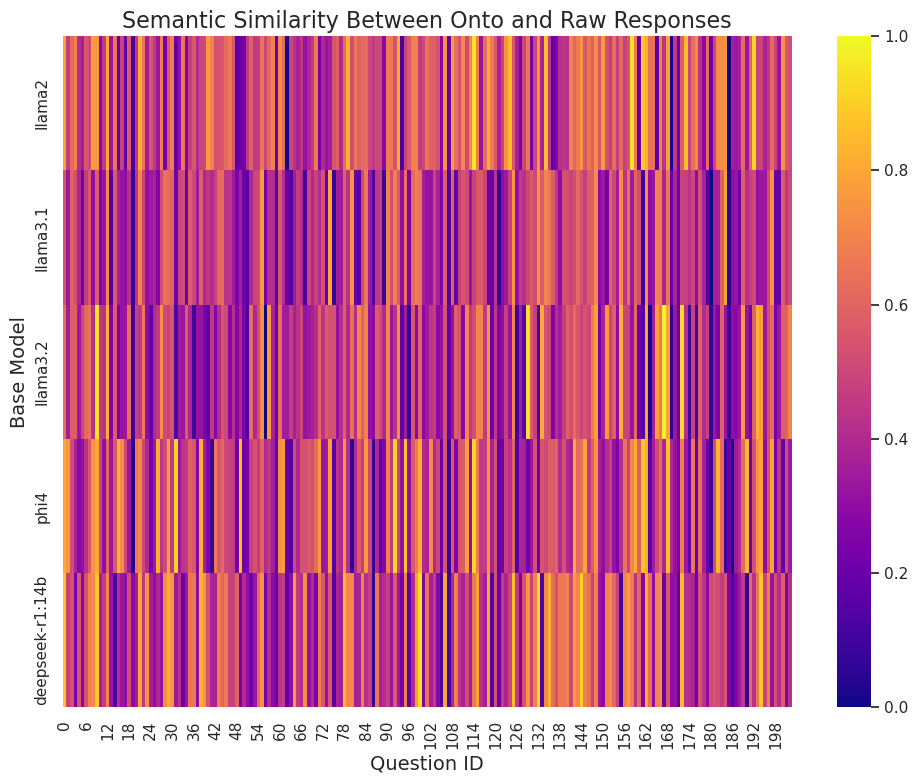

<Figure size 1400x700 with 0 Axes>

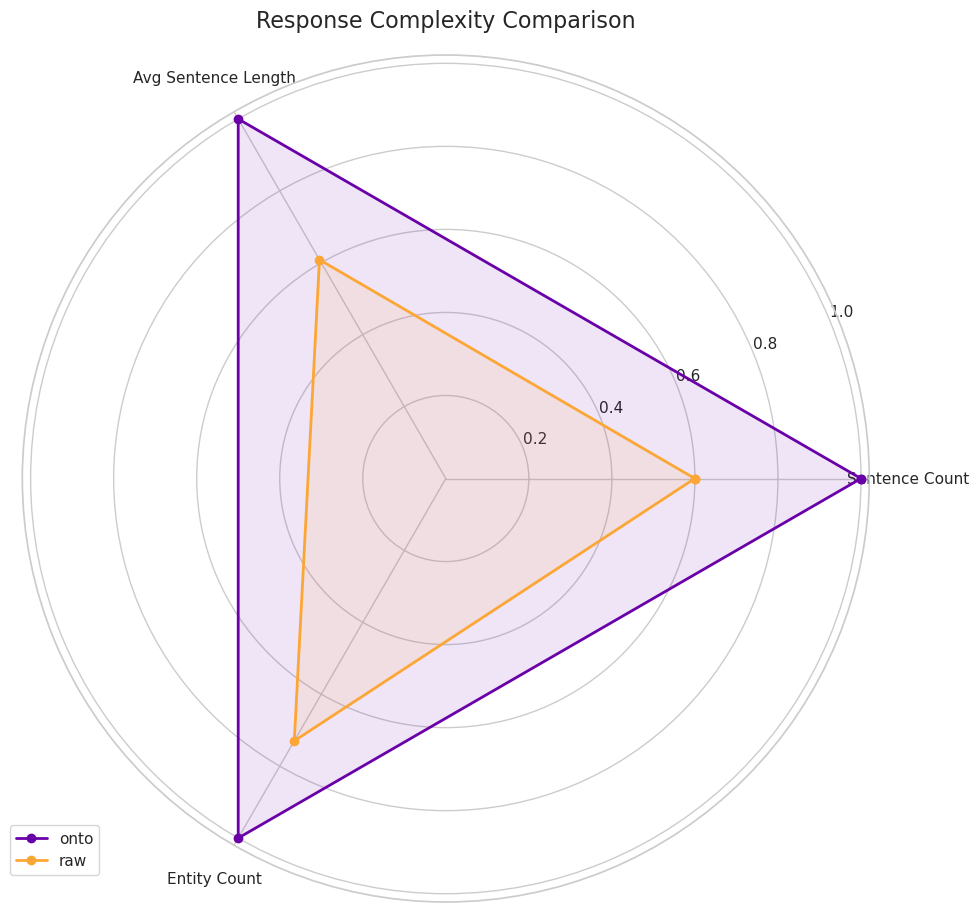

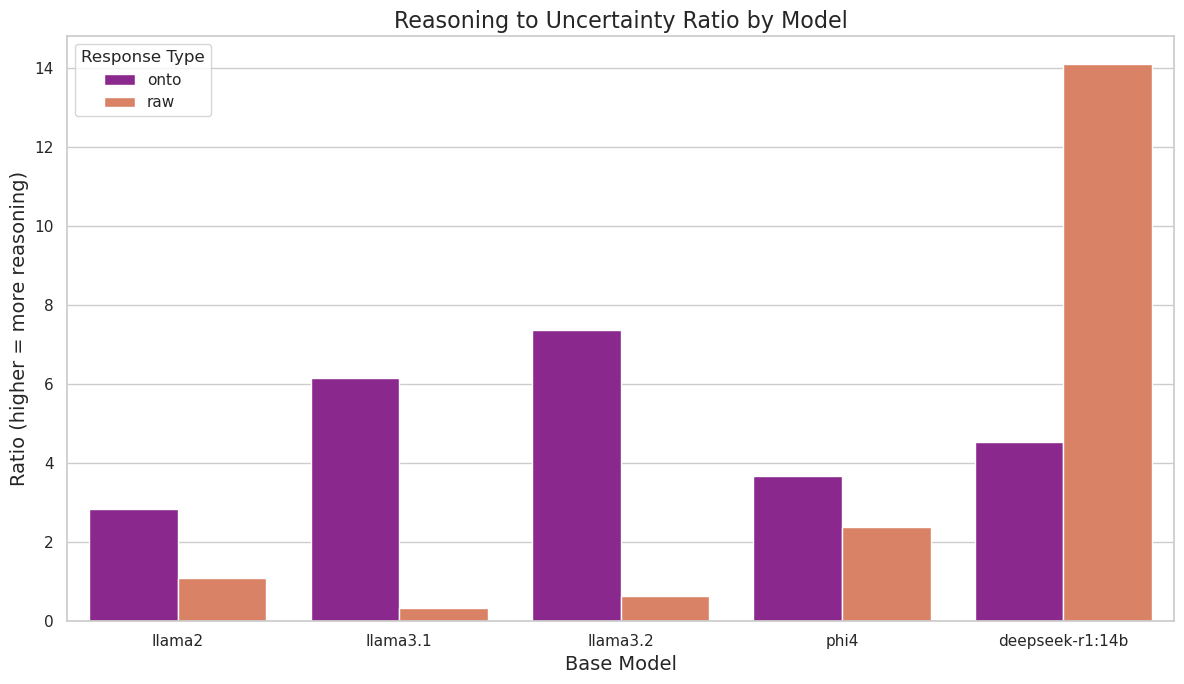

<Figure size 1400x800 with 0 Axes>

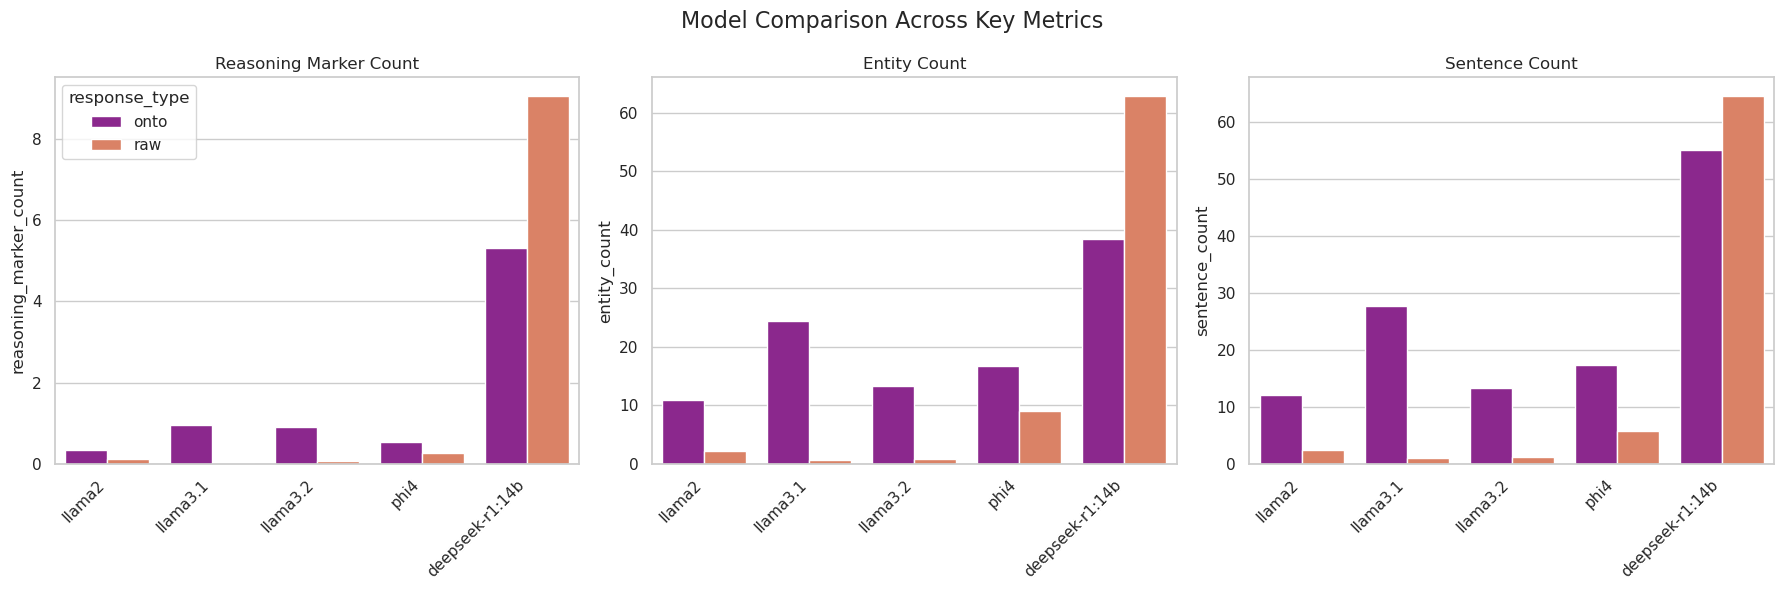

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualize_semantic_analysis(results_file='/home/matt/Proj/Hermeticav2/scripts/semantic_analysis_results_Dual.csv', 
                               similarity_file='/home/matt/Proj/Hermeticav2/scripts/semantic_similarity_results_Dual.csv'):
    # Set the aesthetic style
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': 12})
    
    # Use plasma color palette
    plasma_palette = 'plasma'
    
    # Load the data
    results_df = pd.read_csv(results_file)
    similarity_df = pd.read_csv(similarity_file)
    
    # Define the specific model order
    model_order = ['llama2', 'llama3.1', 'llama3.2', 'phi4', 'deepseek-r1:14b']
    
    # Ensure base_model column follows our order
    if 'base_model' in results_df.columns:
        results_df['base_model'] = pd.Categorical(
            results_df['base_model'], 
            categories=model_order, 
            ordered=True
        )
    
    if 'base_model' in similarity_df.columns:
        similarity_df['base_model'] = pd.Categorical(
            similarity_df['base_model'], 
            categories=model_order, 
            ordered=True
        )
    
    # 1. Create discourse marker comparison visualization
    plt.figure(figsize=(12, 7))
    
    # Prepare data for grouped bar chart
    marker_data = results_df.groupby('response_type')[
        ['reasoning_marker_count', 'uncertainty_marker_count', 'definition_marker_count']
    ].mean().reset_index()
    
    # Reshape for plotting
    marker_data_melted = pd.melt(
        marker_data, 
        id_vars=['response_type'],
        value_vars=['reasoning_marker_count', 'uncertainty_marker_count', 'definition_marker_count'],
        var_name='Marker Type', 
        value_name='Average Count'
    )
    
    # Create the grouped bar chart
    ax = sns.barplot(
        x='Marker Type', 
        y='Average Count', 
        hue='response_type',
        data=marker_data_melted,
        palette=plasma_palette
    )
    
    # Improve readability
    ax.set_xticklabels([x.get_text().replace('_marker_count', '').title() for x in ax.get_xticklabels()])
    plt.title('Discourse Marker Usage Comparison', fontsize=16)
    plt.ylabel('Average Count per Response', fontsize=14)
    plt.xlabel('', fontsize=14)
    plt.legend(title='Response Type', title_fontsize=12)
    plt.tight_layout()
    plt.savefig('discourse_markers_comparison.png', dpi=300)
    
    # 2. Semantic similarity heatmap by model
    if 'base_model' in similarity_df.columns:
        plt.figure(figsize=(10, 8))
        
        # Pivot to create model vs. question heatmap
        if 'question_id' in similarity_df.columns:
            # Sort by our model order
            sorted_similarity_df = similarity_df.sort_values('base_model')
            
            similarity_pivot = sorted_similarity_df.pivot_table(
                index='base_model',
                columns='question_id',
                values='semantic_similarity'
            )
            
            # Ensure models are in correct order
            similarity_pivot = similarity_pivot.reindex(model_order)
            
            # Create heatmap WITHOUT annotations
            sns.heatmap(
                similarity_pivot, 
                annot=False,  # Remove annotations 
                cmap=plasma_palette,
                vmin=0, 
                vmax=1
            )
            plt.title('Semantic Similarity Between Onto and Raw Responses', fontsize=16)
            plt.ylabel('Base Model', fontsize=14)
            plt.xlabel('Question ID', fontsize=14)
            plt.tight_layout()
            plt.savefig('semantic_similarity_heatmap.png', dpi=300)
    
    # 3. Response complexity comparison
    plt.figure(figsize=(14, 7))
    
    # Prepare data
    complexity_data = results_df.groupby('response_type')[
        ['sentence_count', 'avg_sentence_length', 'entity_count']
    ].mean()
    
    # Normalize for radar chart
    complexity_max = complexity_data.max()
    complexity_norm = complexity_data / complexity_max
    
    # Set up the radar chart
    categories = ['Sentence Count', 'Avg Sentence Length', 'Entity Count']
    N = len(categories)
    
    # Create angles for the radar chart
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop
    
    # Get plasma colors for the radar chart
    plasma_colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(complexity_norm.index)))
    
    # Plot radar chart
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    # Add data for each response type
    for i, response_type in enumerate(complexity_norm.index):
        values = complexity_norm.loc[response_type].values.tolist()
        values += values[:1]  # Close the loop
        ax.plot(angles, values, 'o-', linewidth=2, label=response_type, color=plasma_colors[i])
        ax.fill(angles, values, alpha=0.1, color=plasma_colors[i])
    
    # Set category labels and move them outside the circle
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    
    # Fix label placement - move labels outside the circle
    ax.tick_params(pad=15)  # Increase padding to move labels outward
    
    # Adjust figure layout to ensure all labels are visible
    plt.gcf().subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)
    
    # Add legend
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.title('Response Complexity Comparison', fontsize=16, pad=20)  # Add padding to title
    plt.tight_layout()
    plt.savefig('complexity_radar.png', dpi=300)
    
    # 4. Model performance bar chart
    if 'base_model' in results_df.columns:
        plt.figure(figsize=(12, 7))
        
        # Calculate the ratio of reasoning markers to uncertainty markers by model and response type
        results_df['reasoning_to_uncertainty'] = results_df['reasoning_marker_count'] / (results_df['uncertainty_marker_count'] + 0.1)
        
        # Group by model and response type
        reasoning_ratio = results_df.groupby(['base_model', 'response_type'])['reasoning_to_uncertainty'].mean().reset_index()
        
        # Sort by our specified model order
        reasoning_ratio = reasoning_ratio.sort_values('base_model')
        
        # Create grouped bar chart
        sns.barplot(
            x='base_model', 
            y='reasoning_to_uncertainty',
            hue='response_type',
            data=reasoning_ratio,
            palette=plasma_palette,
            order=model_order
        )
        
        plt.title('Reasoning to Uncertainty Ratio by Model', fontsize=16)
        plt.ylabel('Ratio (higher = more reasoning)', fontsize=14)
        plt.xlabel('Base Model', fontsize=14)
        plt.legend(title='Response Type')
        plt.tight_layout()
        plt.savefig('reasoning_ratio_by_model.png', dpi=300)
        
    # 5. Add a new visualization: Model comparison across all metrics
    if 'base_model' in results_df.columns:
        plt.figure(figsize=(14, 8))
        
        # Calculate aggregated metrics by model and response type
        model_metrics = results_df.groupby(['base_model', 'response_type']).agg({
            'reasoning_marker_count': 'mean',
            'entity_count': 'mean',
            'sentence_count': 'mean'
        }).reset_index()
        
        # Create facet grid for the three metrics
        metrics = ['reasoning_marker_count', 'entity_count', 'sentence_count']
        fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
        
        # Plot each metric
        for i, metric in enumerate(metrics):
            sns.barplot(
                x='base_model', 
                y=metric,
                hue='response_type',
                data=model_metrics,
                palette=plasma_palette,
                order=model_order,
                ax=axes[i]
            )
            axes[i].set_title(metric.replace('_', ' ').title())
            axes[i].set_xlabel('')
            # Rotate x-axis labels for better readability
            axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
            if i > 0:
                axes[i].get_legend().remove()
            
        plt.suptitle('Model Comparison Across Key Metrics', fontsize=16)
        plt.tight_layout()
        plt.savefig('model_metrics_comparison.png', dpi=300)
        
    print("Visualizations created successfully!")

if __name__ == "__main__":
    visualize_semantic_analysis()

/tmp/ipykernel_2233882/3556974274.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  marker_data = df_combined.groupby('source')[
/tmp/ipykernel_2233882/3556974274.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([x.get_text().replace('_marker_count', '').title() for x in ax.get_xticklabels()])
/tmp/ipykernel_2233882/3556974274.py:87: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  complexity_data = df_combined.groupby('source')[
posx and posy should be finite values
posx and posy should be finite values

Cross-file comparisons created successfully!


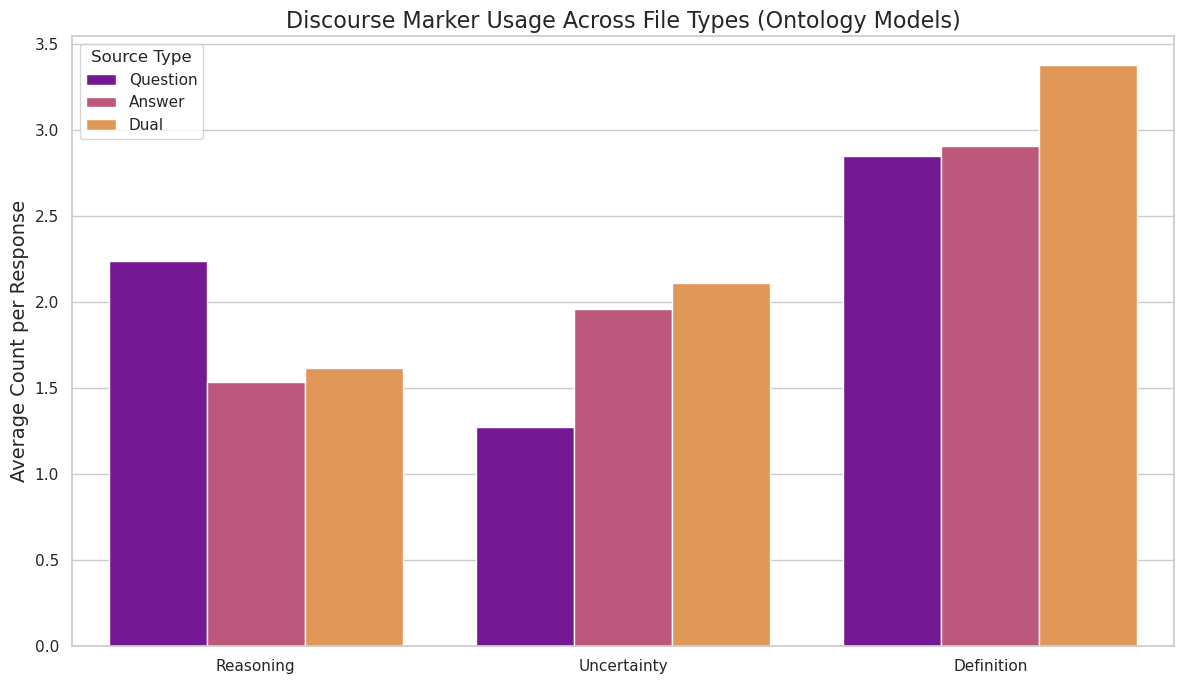

posx and posy should be finite values
posx and posy should be finite values


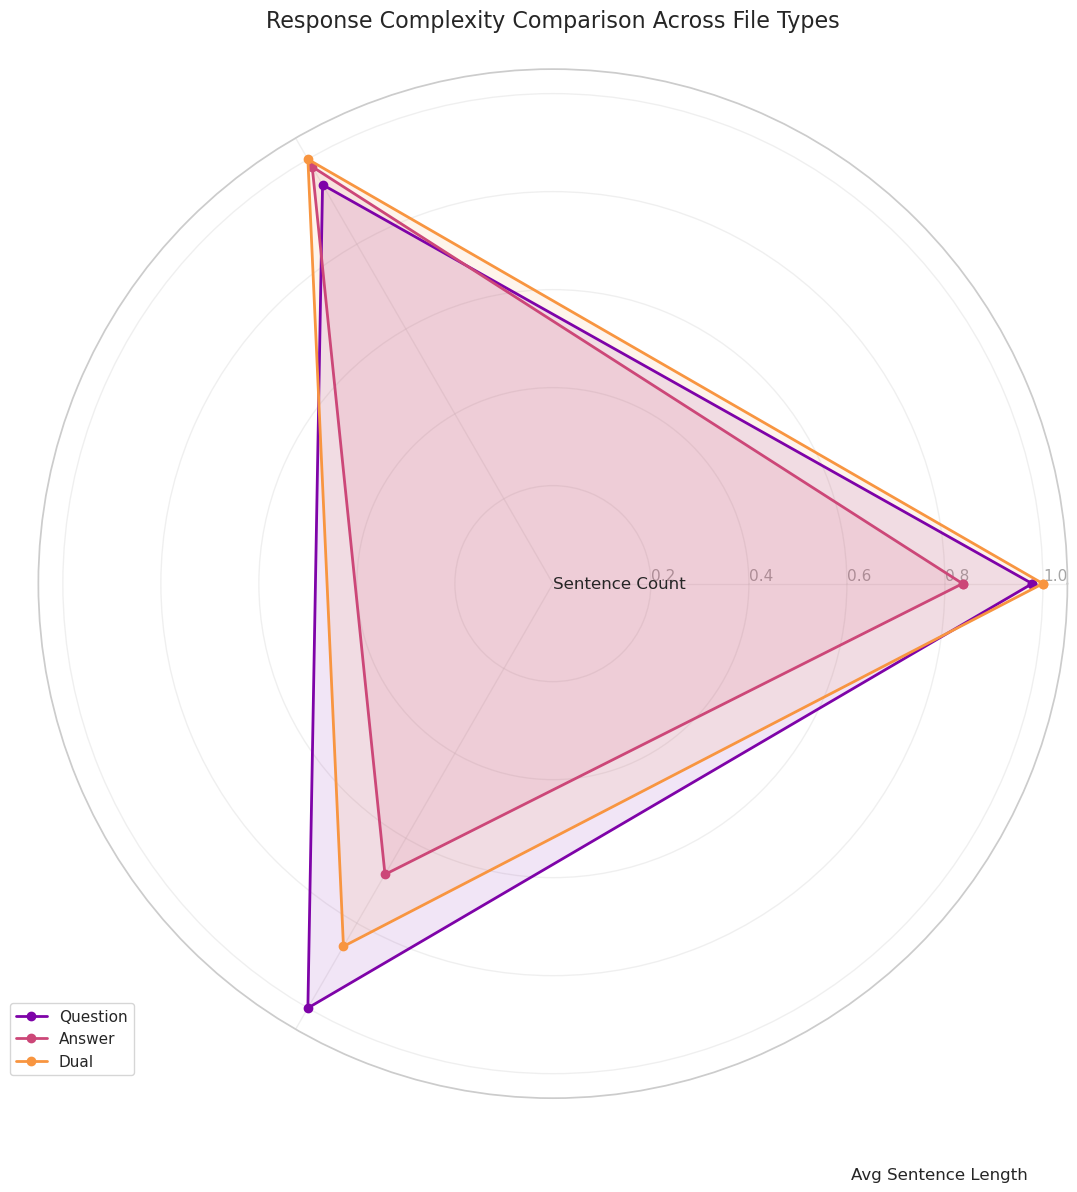

<Figure size 1400x800 with 0 Axes>

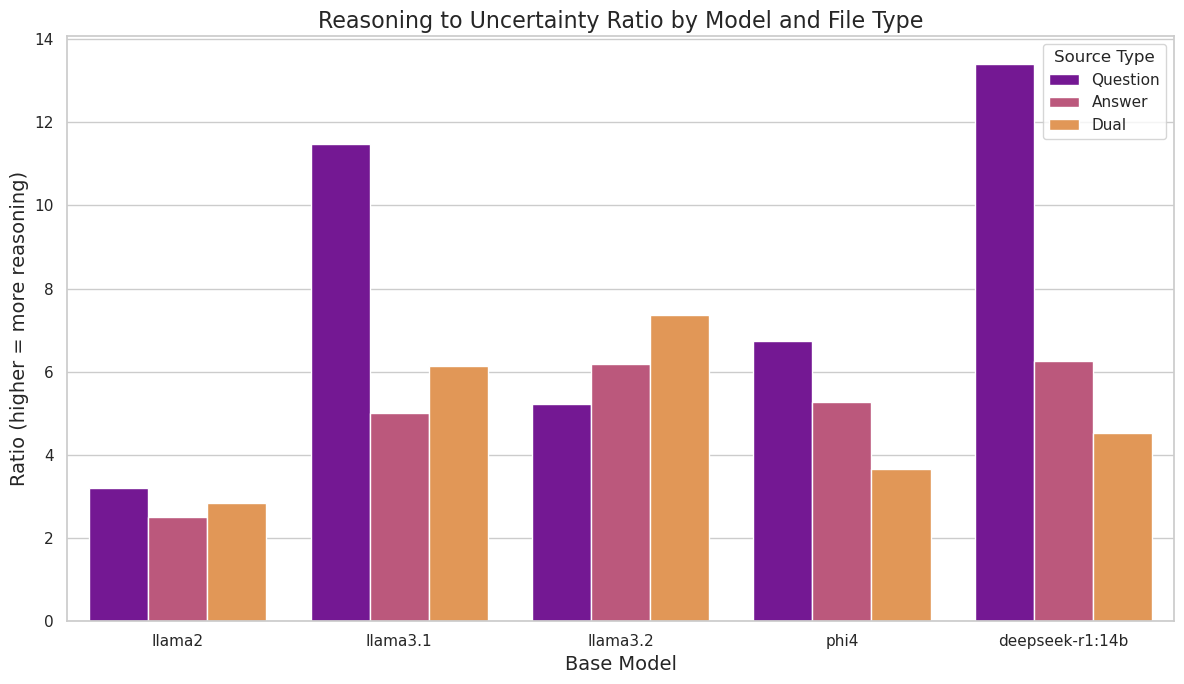

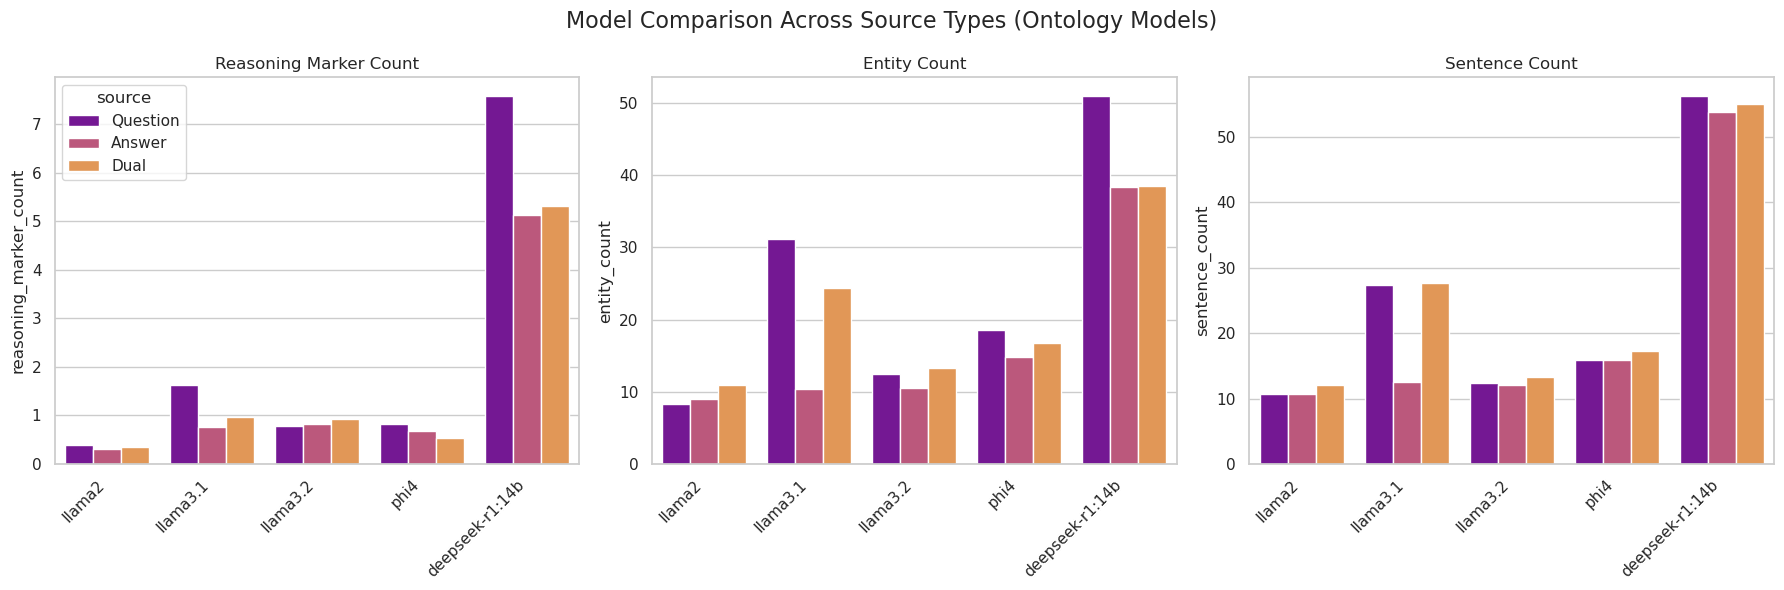

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualize_across_files(question_file, answer_file, dual_file, output_prefix='cross_file'):
    # Set the aesthetic style
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': 12})
    
    # Define number of file types and get plasma colors
    file_count = 3  # Question, Answer, Dual
    plasma_colors = sns.color_palette("plasma", file_count)
    
    # Load the data from each file
    df_question = pd.read_csv(question_file)
    df_answer = pd.read_csv(answer_file)
    df_dual = pd.read_csv(dual_file)
    
    # Add source column to each dataframe
    df_question['source'] = 'Question'
    df_answer['source'] = 'Answer'
    df_dual['source'] = 'Dual'
    
    # Combine data but only keep ontology responses
    df_question = df_question[df_question['response_type'] == 'onto']
    df_answer = df_answer[df_answer['response_type'] == 'onto']
    df_dual = df_dual[df_dual['response_type'] == 'onto']
    
    # Combine the dataframes
    df_combined = pd.concat([df_question, df_answer, df_dual])
    
    # Define the specific model order and source order
    model_order = ['llama2', 'llama3.1', 'llama3.2', 'phi4', 'deepseek-r1:14b']
    source_order = ['Question', 'Answer', 'Dual']
    
    # Ensure ordering is consistent
    df_combined['base_model'] = pd.Categorical(
        df_combined['base_model'], 
        categories=model_order, 
        ordered=True
    )
    
    df_combined['source'] = pd.Categorical(
        df_combined['source'], 
        categories=source_order, 
        ordered=True
    )
    
    # 1. Create discourse marker comparison visualization
    plt.figure(figsize=(12, 7))
    
    # Prepare data for grouped bar chart
    marker_data = df_combined.groupby('source')[
        ['reasoning_marker_count', 'uncertainty_marker_count', 'definition_marker_count']
    ].mean().reset_index()
    
    # Reshape for plotting
    marker_data_melted = pd.melt(
        marker_data, 
        id_vars=['source'],
        value_vars=['reasoning_marker_count', 'uncertainty_marker_count', 'definition_marker_count'],
        var_name='Marker Type', 
        value_name='Average Count'
    )
    
    # Create the grouped bar chart
    ax = sns.barplot(
        x='Marker Type', 
        y='Average Count', 
        hue='source',
        data=marker_data_melted,
        palette=plasma_colors,
        hue_order=source_order
    )
    
    # Improve readability
    ax.set_xticklabels([x.get_text().replace('_marker_count', '').title() for x in ax.get_xticklabels()])
    plt.title('Discourse Marker Usage Across File Types (Ontology Models)', fontsize=16)
    plt.ylabel('Average Count per Response', fontsize=14)
    plt.xlabel('', fontsize=14)
    plt.legend(title='Source Type', title_fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{output_prefix}_discourse_markers.png', dpi=300)
    
    # 2. Response complexity comparison radar chart
    complexity_data = df_combined.groupby('source')[
        ['sentence_count', 'avg_sentence_length', 'entity_count']
    ].mean()
    
    # Normalize for radar chart
    complexity_max = complexity_data.max()
    complexity_norm = complexity_data / complexity_max
    
    # Set up the radar chart
    categories = ['Sentence Count', 'Avg Sentence Length', 'Entity Count']
    N = len(categories)
    
    # Create angles for the radar chart
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop
    
    # IMPROVED RADAR CHART with better label positioning
    fig = plt.figure(figsize=(12, 12))
    ax = fig.add_subplot(111, polar=True)
    
    # Add data for each source type
    for i, source in enumerate(source_order):
        if source in complexity_norm.index:
            values = complexity_norm.loc[source].values.tolist()
            values += values[:1]  # Close the loop
            ax.plot(angles, values, 'o-', linewidth=2, label=source, color=plasma_colors[i])
            ax.fill(angles, values, alpha=0.1, color=plasma_colors[i])
    
    # Set category labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([])  # First remove default labels
    
    # Manually place labels outside the circle with better positioning
    for i, label in enumerate(categories):
        angle = angles[i]
        # Use an even larger radius (1.8) to ensure labels are completely outside the circle
        x = 1.8 * np.cos(angle)
        y = 1.8 * np.sin(angle)
        
        # Adjust text alignment based on position
        if angle == 0:
            ha, va = 'left', 'center'
        elif 0 < angle < np.pi/2:
            ha, va = 'left', 'bottom'
        elif angle == np.pi/2:
            ha, va = 'center', 'bottom'
        elif np.pi/2 < angle < np.pi:
            ha, va = 'right', 'bottom'
        elif angle == np.pi:
            ha, va = 'right', 'center'
        elif np.pi < angle < 3*np.pi/2:
            ha, va = 'right', 'top'
        elif angle == 3*np.pi/2:
            ha, va = 'center', 'top'
        else:
            ha, va = 'left', 'top'
            
        # Add the label
        ax.text(x, y, label, ha=ha, va=va, fontsize=12)
    
    # Customize grid and axis
    ax.grid(True, alpha=0.3)
    ax.set_rlabel_position(0)
    plt.yticks(color="grey", alpha=0.7)
    
    # Set fixed limits for the radar chart to ensure consistency
    ax.set_ylim(0, 1.05)
    
    # Add legend
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.title('Response Complexity Comparison Across File Types', fontsize=16, pad=30)
    
    # Save the figure
    plt.tight_layout()
    plt.savefig(f'{output_prefix}_complexity_radar.png', dpi=300)
    
    # 3. Model performance comparison across source types
    plt.figure(figsize=(14, 8))
    
    # Calculate reasoning to uncertainty ratio
    df_combined['reasoning_to_uncertainty'] = df_combined['reasoning_marker_count'] / (df_combined['uncertainty_marker_count'] + 0.1)
    
    # Group by model and source
    model_source_metrics = df_combined.groupby(['base_model', 'source'])['reasoning_to_uncertainty'].mean().reset_index()
    
    # Create grouped bar chart
    plt.figure(figsize=(12, 7))
    sns.barplot(
        x='base_model', 
        y='reasoning_to_uncertainty',
        hue='source',
        data=model_source_metrics,
        palette=plasma_colors,
        order=model_order,
        hue_order=source_order
    )
    
    plt.title('Reasoning to Uncertainty Ratio by Model and File Type', fontsize=16)
    plt.ylabel('Ratio (higher = more reasoning)', fontsize=14)
    plt.xlabel('Base Model', fontsize=14)
    plt.legend(title='Source Type')
    plt.tight_layout()
    plt.savefig(f'{output_prefix}_reasoning_ratio.png', dpi=300)
    
    # 4. Comparative metrics across models and sources
    metrics = ['reasoning_marker_count', 'entity_count', 'sentence_count']
    
    # Create a facet grid for these metrics
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
    
    # Calculate aggregated metrics
    model_metrics = df_combined.groupby(['base_model', 'source']).agg({
        'reasoning_marker_count': 'mean',
        'entity_count': 'mean',
        'sentence_count': 'mean'
    }).reset_index()
    
    # Plot each metric
    for i, metric in enumerate(metrics):
        sns.barplot(
            x='base_model', 
            y=metric,
            hue='source',
            data=model_metrics,
            palette=plasma_colors,
            order=model_order,
            hue_order=source_order,
            ax=axes[i]
        )
        axes[i].set_title(metric.replace('_', ' ').title())
        axes[i].set_xlabel('')
        # Rotate x-axis labels for better readability
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
        if i > 0:
            axes[i].get_legend().remove()
        
    plt.suptitle('Model Comparison Across Source Types (Ontology Models)', fontsize=16)
    plt.tight_layout()
    plt.savefig(f'{output_prefix}_metrics_comparison.png', dpi=300)
    
    print("Cross-file comparisons created successfully!")

if __name__ == "__main__":
    # Replace with your actual file paths
    question_file = '/home/matt/Proj/Hermeticav2/scripts/semantic_analysis_results_Question.csv'
    answer_file = '/home/matt/Proj/Hermeticav2/scripts/semantic_analysis_results.csv'
    dual_file = '/home/matt/Proj/Hermeticav2/scripts/semantic_analysis_results_Dual.csv'
    
    visualize_across_files(question_file, answer_file, dual_file)

/tmp/ipykernel_2233882/2846359523.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  marker_data = df_combined.groupby('source')[
/tmp/ipykernel_2233882/2846359523.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([x.get_text().replace('_marker_count', '').title() for x in ax.get_xticklabels()])
/tmp/ipykernel_2233882/2846359523.py:87: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  complexity_data = df_combined.groupby('source')[
posx and posy should be finite values
posx and posy should be finite values

Cross-file comparisons created successfully!


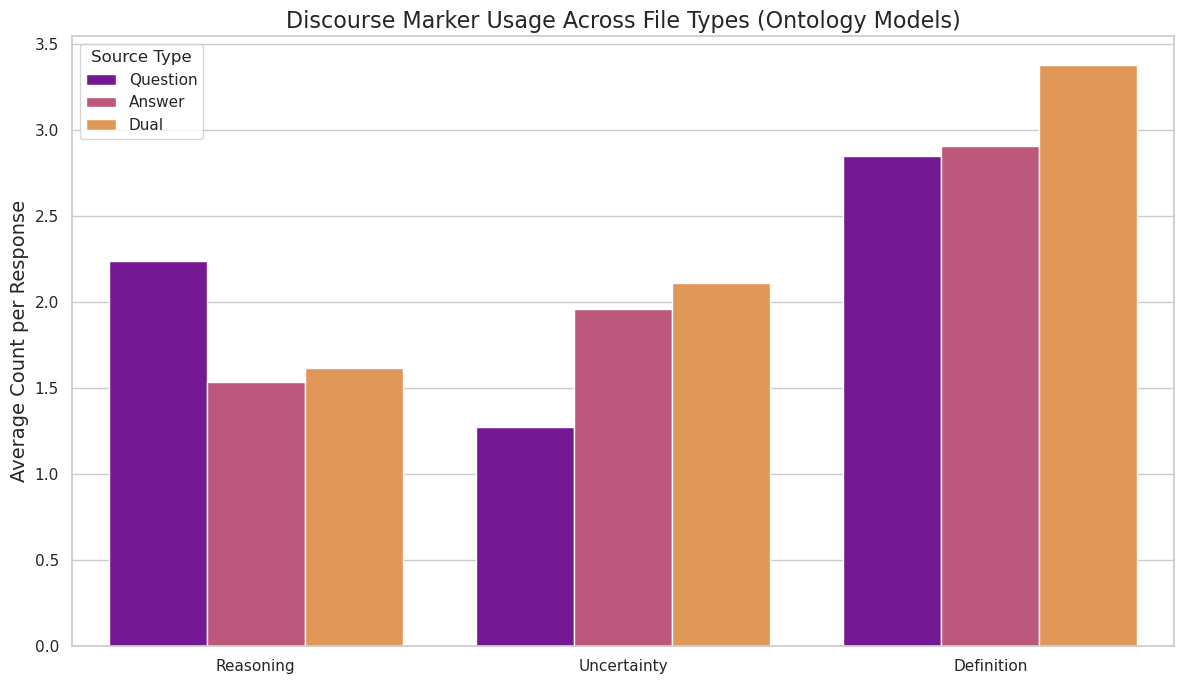

posx and posy should be finite values
posx and posy should be finite values


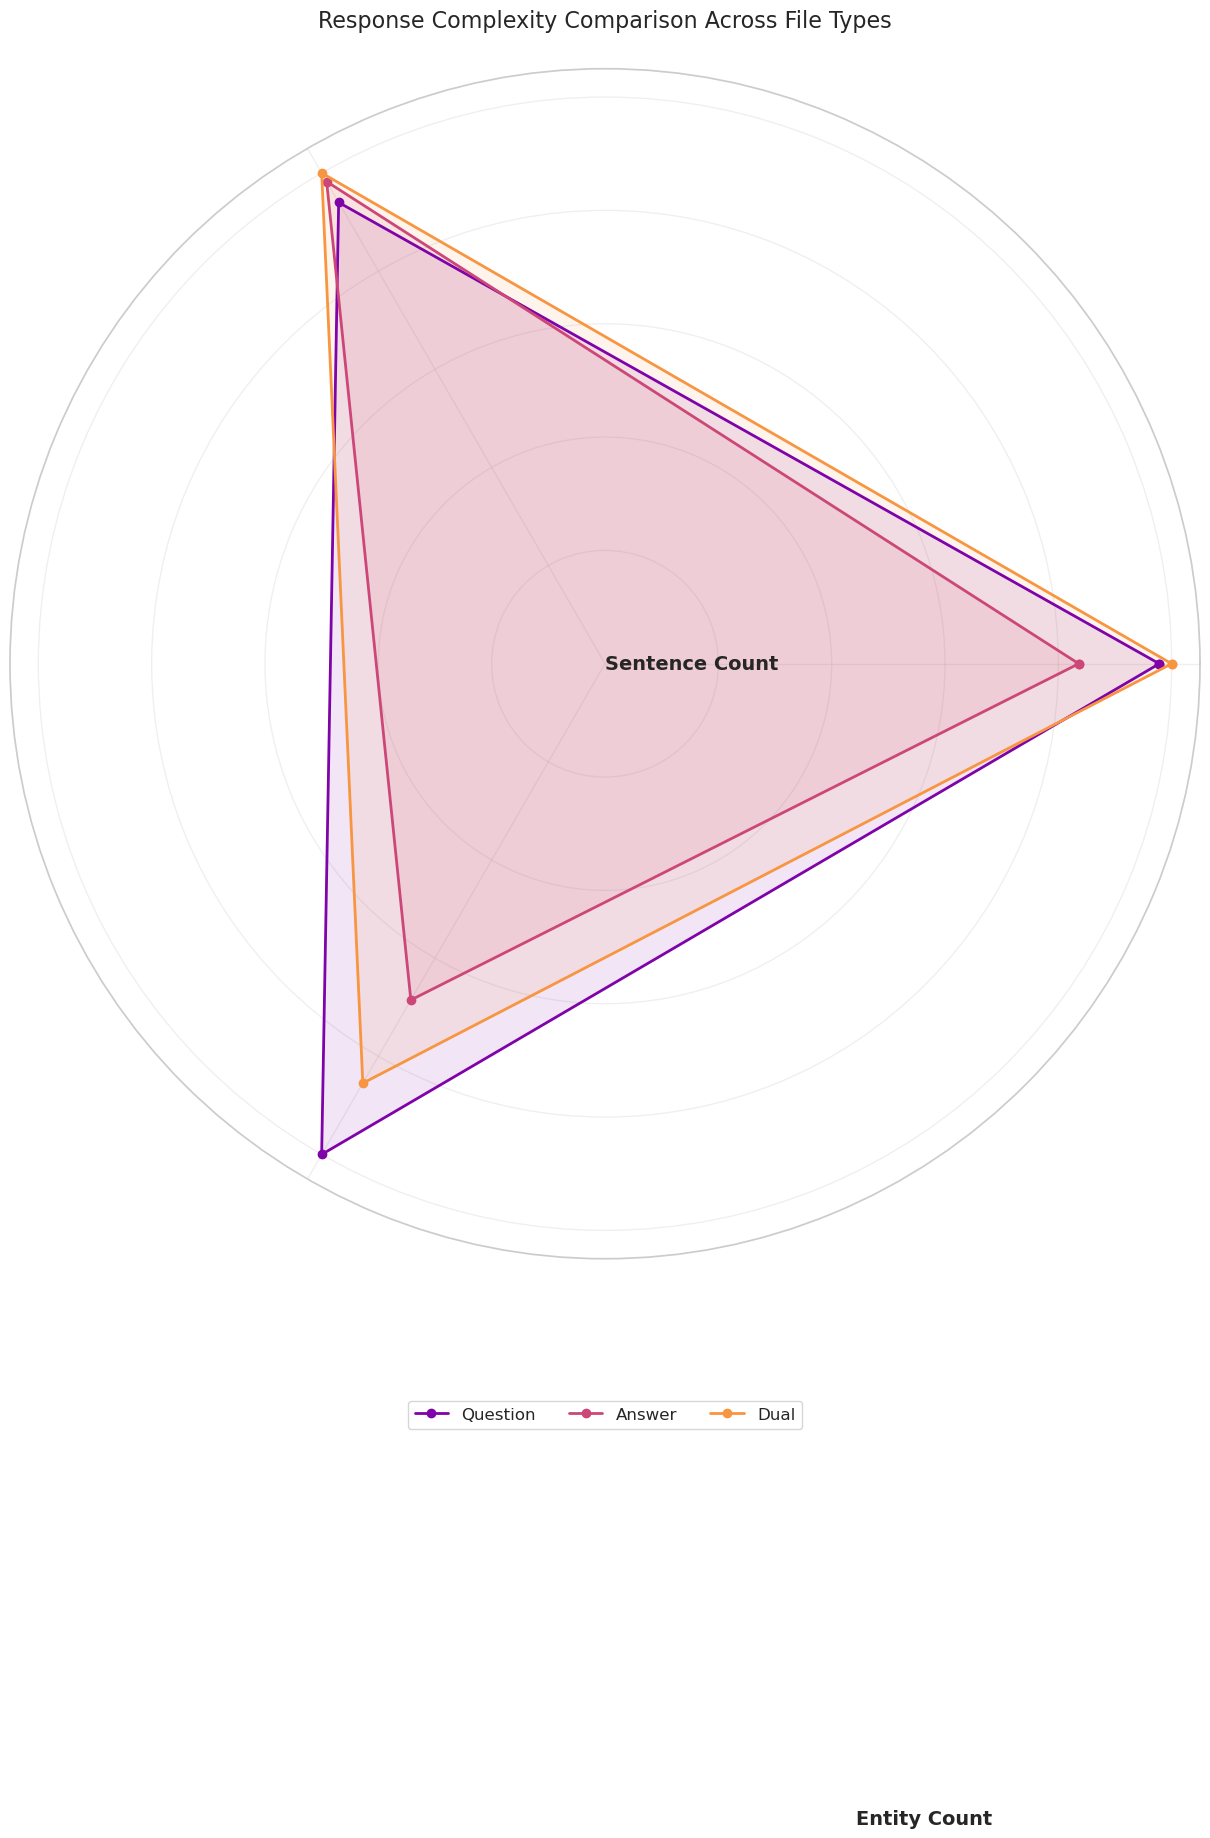

<Figure size 1400x800 with 0 Axes>

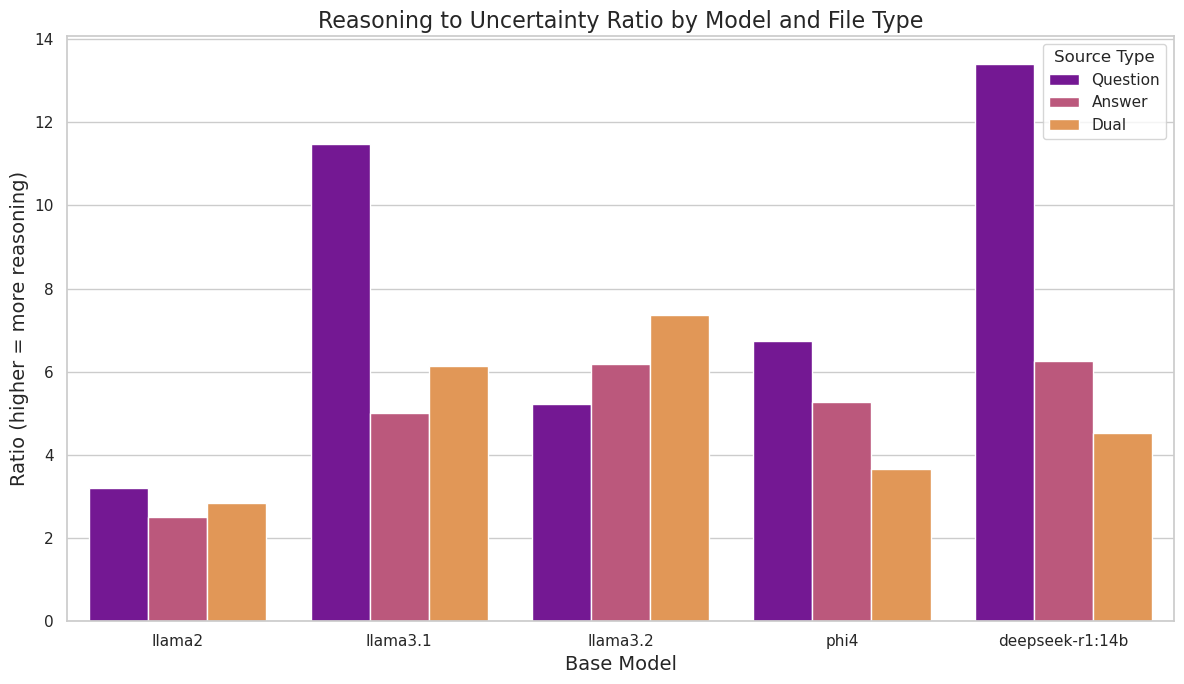

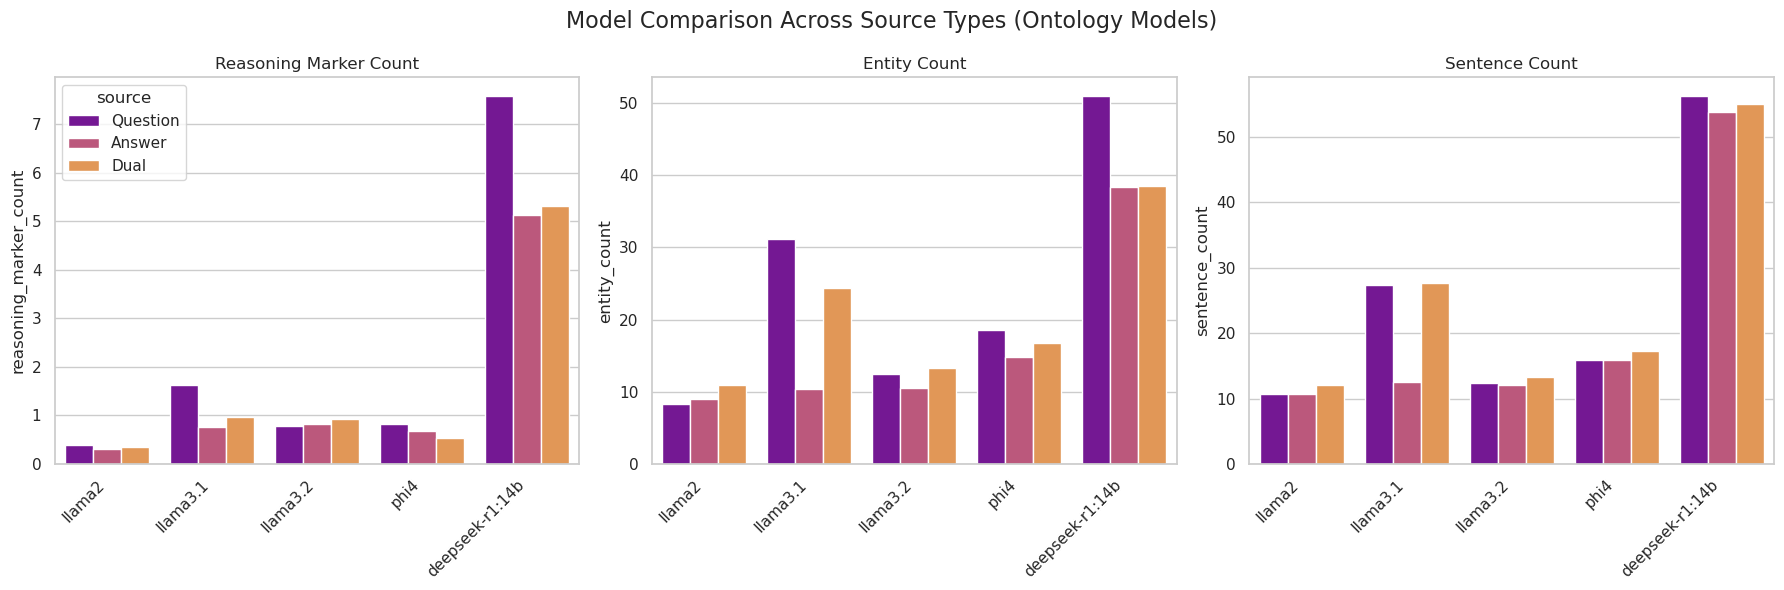

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualize_across_files(question_file, answer_file, dual_file, output_prefix='cross_file'):
    # Set the aesthetic style
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': 12})
    
    # Define number of file types and get plasma colors
    file_count = 3  # Question, Answer, Dual
    plasma_colors = sns.color_palette("plasma", file_count)
    
    # Load the data from each file
    df_question = pd.read_csv(question_file)
    df_answer = pd.read_csv(answer_file)
    df_dual = pd.read_csv(dual_file)
    
    # Add source column to each dataframe
    df_question['source'] = 'Question'
    df_answer['source'] = 'Answer'
    df_dual['source'] = 'Dual'
    
    # Combine data but only keep ontology responses
    df_question = df_question[df_question['response_type'] == 'onto']
    df_answer = df_answer[df_answer['response_type'] == 'onto']
    df_dual = df_dual[df_dual['response_type'] == 'onto']
    
    # Combine the dataframes
    df_combined = pd.concat([df_question, df_answer, df_dual])
    
    # Define the specific model order and source order
    model_order = ['llama2', 'llama3.1', 'llama3.2', 'phi4', 'deepseek-r1:14b']
    source_order = ['Question', 'Answer', 'Dual']
    
    # Ensure ordering is consistent
    df_combined['base_model'] = pd.Categorical(
        df_combined['base_model'], 
        categories=model_order, 
        ordered=True
    )
    
    df_combined['source'] = pd.Categorical(
        df_combined['source'], 
        categories=source_order, 
        ordered=True
    )
    
    # 1. Create discourse marker comparison visualization
    plt.figure(figsize=(12, 7))
    
    # Prepare data for grouped bar chart
    marker_data = df_combined.groupby('source')[
        ['reasoning_marker_count', 'uncertainty_marker_count', 'definition_marker_count']
    ].mean().reset_index()
    
    # Reshape for plotting
    marker_data_melted = pd.melt(
        marker_data, 
        id_vars=['source'],
        value_vars=['reasoning_marker_count', 'uncertainty_marker_count', 'definition_marker_count'],
        var_name='Marker Type', 
        value_name='Average Count'
    )
    
    # Create the grouped bar chart - use plasma_colors directly
    ax = sns.barplot(
        x='Marker Type', 
        y='Average Count', 
        hue='source',
        data=marker_data_melted,
        palette=plasma_colors,
        hue_order=source_order
    )
    
    # Improve readability
    ax.set_xticklabels([x.get_text().replace('_marker_count', '').title() for x in ax.get_xticklabels()])
    plt.title('Discourse Marker Usage Across File Types (Ontology Models)', fontsize=16)
    plt.ylabel('Average Count per Response', fontsize=14)
    plt.xlabel('', fontsize=14)
    plt.legend(title='Source Type', title_fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{output_prefix}_discourse_markers.png', dpi=300)
    
    # 2. Response complexity comparison radar chart with labels ENTIRELY OUTSIDE the figure
    complexity_data = df_combined.groupby('source')[
        ['sentence_count', 'avg_sentence_length', 'entity_count']
    ].mean()
    
    # Normalize for radar chart
    complexity_max = complexity_data.max()
    complexity_norm = complexity_data / complexity_max
    
    # IMPROVED RADAR CHART with labels completely outside the figure
    plt.figure(figsize=(14, 14))  # Larger figure size to accommodate external labels

    # Create the polar axes with extra padding
    ax = plt.subplot(111, polar=True)

    # Get specific padding for labels outside the plot
    fig = plt.gcf()
    fig.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.05)

    # Set up the radar chart
    categories = ['Sentence Count', 'Entity Count', 'Avg Sentence Length']
    N = len(categories)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop

    # Add data for each source type
    for i, source in enumerate(source_order):
        if source in complexity_norm.index:
            values = complexity_norm.loc[source].values.tolist()
            values += values[:1]  # Close the loop
            ax.plot(angles, values, 'o-', linewidth=2, label=source, color=plasma_colors[i])
            ax.fill(angles, values, alpha=0.1, color=plasma_colors[i])

    # Remove the default axis labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([])

    # Manually position labels far outside the plot
    label_padding = 2.5  # This should place labels well outside the figure

    for i, label in enumerate(categories):
        angle = angles[i]
        
        # Calculate position outside the circle
        x = label_padding * np.cos(angle)
        y = label_padding * np.sin(angle)
        
        # Determine text alignment based on angle position
        if angle == 0:
            ha, va = 'left', 'center'
        elif 0 < angle < np.pi/2:
            ha, va = 'left', 'bottom'
        elif angle == np.pi/2:
            ha, va = 'center', 'bottom'
        elif np.pi/2 < angle < np.pi:
            ha, va = 'right', 'bottom'
        elif angle == np.pi:
            ha, va = 'right', 'center'
        elif np.pi < angle < 3*np.pi/2:
            ha, va = 'right', 'top'
        elif angle == 3*np.pi/2:
            ha, va = 'center', 'top'
        else:
            ha, va = 'left', 'top'
        
        # Add the label with increased font size for better visibility
        ax.text(x, y, label, ha=ha, va=va, fontsize=14, fontweight='bold')

    # Set axis limits to ensure we see all the data but not the labels
    ax.set_ylim(0, 1.05)

    # Remove radial labels to make the chart cleaner
    ax.set_yticklabels([])

    # Add grid for reference
    ax.grid(True, alpha=0.3)

    # Add legend
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=12)

    # Title with extra padding
    plt.title('Response Complexity Comparison Across File Types', fontsize=16, pad=30)

    # Save the figure with tight_layout=False to preserve our manual adjustments
    plt.savefig(f'{output_prefix}_complexity_radar.png', dpi=300, bbox_inches='tight')
    
    # 3. Model performance comparison across source types
    plt.figure(figsize=(14, 8))
    
    # Calculate reasoning to uncertainty ratio
    df_combined['reasoning_to_uncertainty'] = df_combined['reasoning_marker_count'] / (df_combined['uncertainty_marker_count'] + 0.1)
    
    # Group by model and source
    model_source_metrics = df_combined.groupby(['base_model', 'source'])['reasoning_to_uncertainty'].mean().reset_index()
    
    # Create grouped bar chart
    plt.figure(figsize=(12, 7))
    sns.barplot(
        x='base_model', 
        y='reasoning_to_uncertainty',
        hue='source',
        data=model_source_metrics,
        palette=plasma_colors,
        order=model_order,
        hue_order=source_order
    )
    
    plt.title('Reasoning to Uncertainty Ratio by Model and File Type', fontsize=16)
    plt.ylabel('Ratio (higher = more reasoning)', fontsize=14)
    plt.xlabel('Base Model', fontsize=14)
    plt.legend(title='Source Type')
    plt.tight_layout()
    plt.savefig(f'{output_prefix}_reasoning_ratio.png', dpi=300)
    
    # 4. Comparative metrics across models and sources
    metrics = ['reasoning_marker_count', 'entity_count', 'sentence_count']
    
    # Create a facet grid for these metrics
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
    
    # Calculate aggregated metrics
    model_metrics = df_combined.groupby(['base_model', 'source']).agg({
        'reasoning_marker_count': 'mean',
        'entity_count': 'mean',
        'sentence_count': 'mean'
    }).reset_index()
    
    # Plot each metric
    for i, metric in enumerate(metrics):
        sns.barplot(
            x='base_model', 
            y=metric,
            hue='source',
            data=model_metrics,
            palette=plasma_colors,
            order=model_order,
            hue_order=source_order,
            ax=axes[i]
        )
        axes[i].set_title(metric.replace('_', ' ').title())
        axes[i].set_xlabel('')
        # Rotate x-axis labels for better readability
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
        if i > 0:
            axes[i].get_legend().remove()
        
    plt.suptitle('Model Comparison Across Source Types (Ontology Models)', fontsize=16)
    plt.tight_layout()
    plt.savefig(f'{output_prefix}_metrics_comparison.png', dpi=300)
    
    print("Cross-file comparisons created successfully!")

if __name__ == "__main__":
    # Replace with your actual file paths
    question_file = '/home/matt/Proj/Hermeticav2/scripts/semantic_analysis_results_Question.csv'
    answer_file = '/home/matt/Proj/Hermeticav2/scripts/semantic_analysis_results.csv'
    dual_file = '/home/matt/Proj/Hermeticav2/scripts/semantic_analysis_results_Dual.csv'
    
    visualize_across_files(question_file, answer_file, dual_file)

/tmp/ipykernel_2233882/3838356424.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  marker_data = df_combined.groupby('source')[
/tmp/ipykernel_2233882/3838356424.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([x.get_text().replace('_marker_count', '').title() for x in ax.get_xticklabels()])
/tmp/ipykernel_2233882/3838356424.py:87: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  complexity_data = df_combined.groupby('source')[
/tmp/ipykernel_2233882/3838356424.py:132: FutureWarning: The default of obs

Cross-file comparisons created successfully!


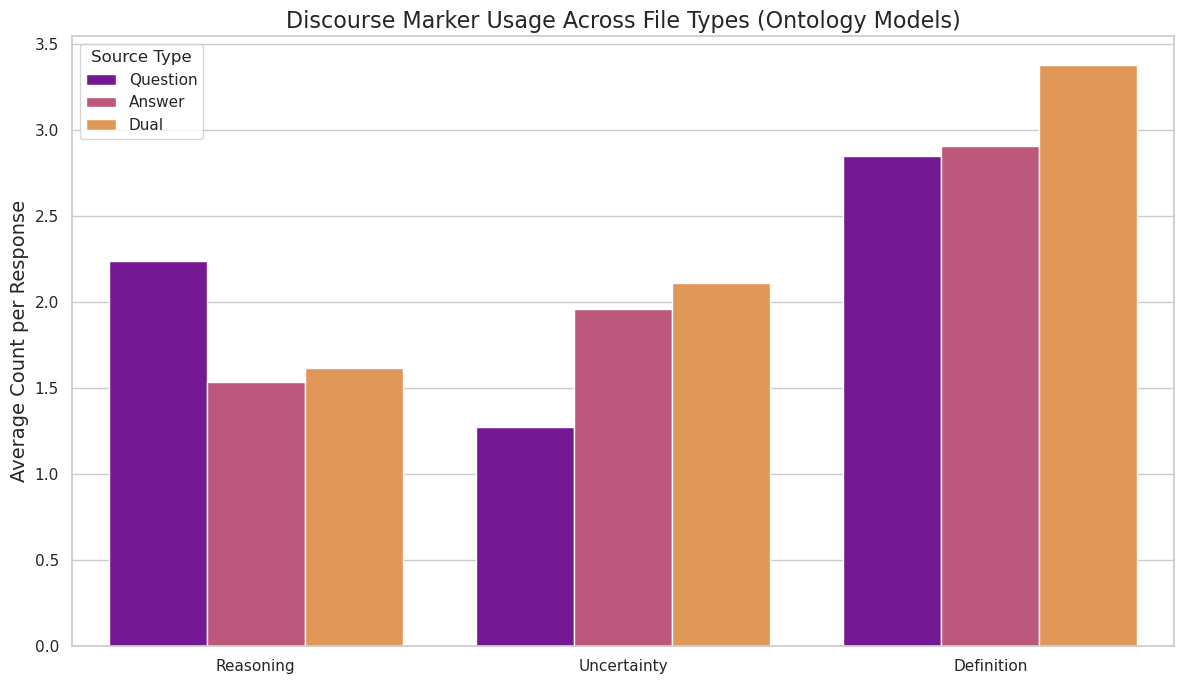

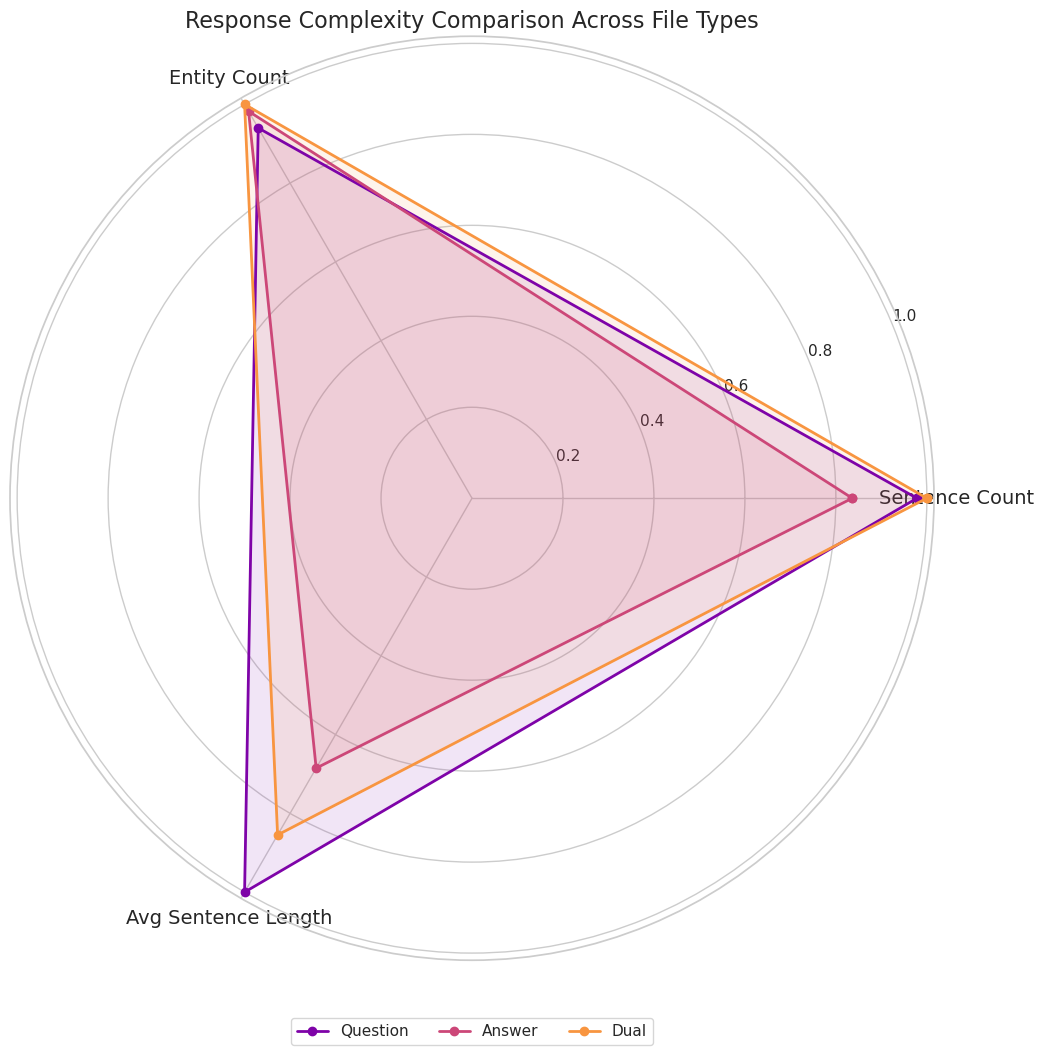

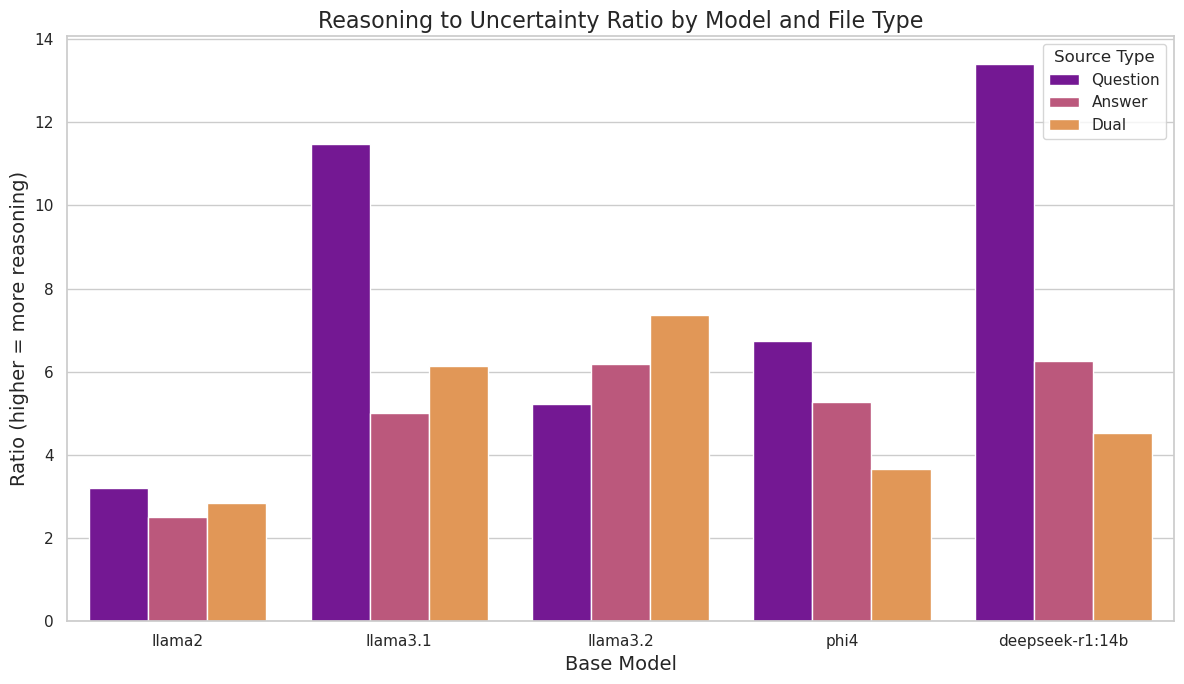

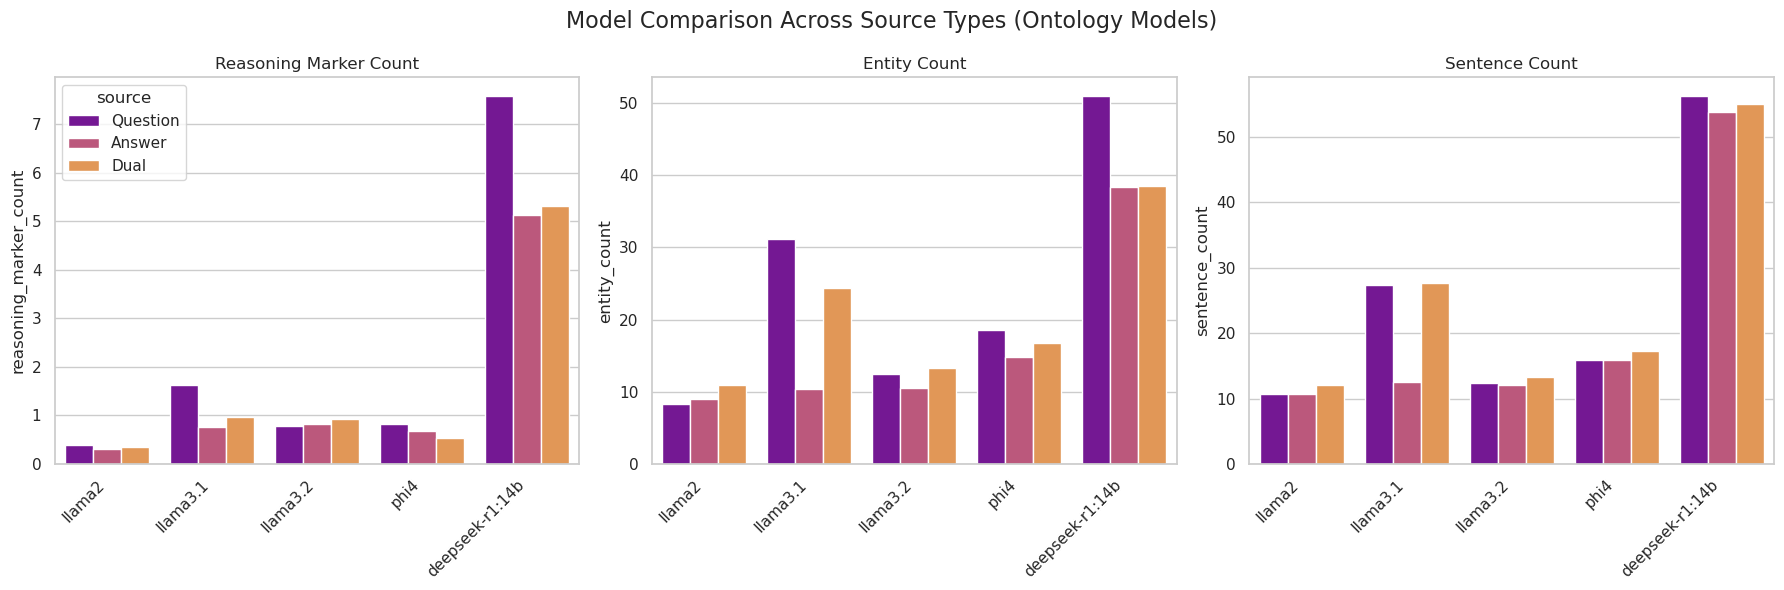

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualize_across_files(question_file, answer_file, dual_file, output_prefix='cross_file'):
    # Set the aesthetic style
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': 12})
    
    # Define plasma colors
    file_count = 3  # Question, Answer, Dual
    plasma_colors = sns.color_palette("plasma", file_count)
    
    # Load the data from each file
    df_question = pd.read_csv(question_file)
    df_answer = pd.read_csv(answer_file)
    df_dual = pd.read_csv(dual_file)
    
    # Add source column to each dataframe
    df_question['source'] = 'Question'
    df_answer['source'] = 'Answer'
    df_dual['source'] = 'Dual'
    
    # Combine data but only keep ontology responses
    df_question = df_question[df_question['response_type'] == 'onto']
    df_answer = df_answer[df_answer['response_type'] == 'onto']
    df_dual = df_dual[df_dual['response_type'] == 'onto']
    
    # Combine the dataframes
    df_combined = pd.concat([df_question, df_answer, df_dual])
    
    # Define the specific model order and source order
    model_order = ['llama2', 'llama3.1', 'llama3.2', 'phi4', 'deepseek-r1:14b']
    source_order = ['Question', 'Answer', 'Dual']
    
    # Ensure ordering is consistent
    df_combined['base_model'] = pd.Categorical(
        df_combined['base_model'], 
        categories=model_order, 
        ordered=True
    )
    
    df_combined['source'] = pd.Categorical(
        df_combined['source'], 
        categories=source_order, 
        ordered=True
    )
    
    # 1. Create discourse marker comparison visualization
    plt.figure(figsize=(12, 7))
    
    # Prepare data for grouped bar chart
    marker_data = df_combined.groupby('source')[
        ['reasoning_marker_count', 'uncertainty_marker_count', 'definition_marker_count']
    ].mean().reset_index()
    
    # Reshape for plotting
    marker_data_melted = pd.melt(
        marker_data, 
        id_vars=['source'],
        value_vars=['reasoning_marker_count', 'uncertainty_marker_count', 'definition_marker_count'],
        var_name='Marker Type', 
        value_name='Average Count'
    )
    
    # Create the grouped bar chart
    ax = sns.barplot(
        x='Marker Type', 
        y='Average Count', 
        hue='source',
        data=marker_data_melted,
        palette=plasma_colors,
        hue_order=source_order
    )
    
    # Improve readability
    ax.set_xticklabels([x.get_text().replace('_marker_count', '').title() for x in ax.get_xticklabels()])
    plt.title('Discourse Marker Usage Across File Types (Ontology Models)', fontsize=16)
    plt.ylabel('Average Count per Response', fontsize=14)
    plt.xlabel('', fontsize=14)
    plt.legend(title='Source Type', title_fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{output_prefix}_discourse_markers.png', dpi=300)
    
    # 2. Response complexity comparison radar chart - fixed version
    complexity_data = df_combined.groupby('source')[
        ['sentence_count', 'avg_sentence_length', 'entity_count']
    ].mean()

    # Normalize for radar chart
    complexity_max = complexity_data.max()
    complexity_norm = complexity_data / complexity_max

    # Create the plot
    plt.figure(figsize=(12, 12))
    ax = plt.subplot(111, polar=True)

    # Setup
    categories = ['Sentence Count', 'Entity Count', 'Avg Sentence Length']
    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
    angles_plot = np.append(angles, angles[0])  # Close the loop

    # Plot each data series
    for i, source in enumerate(source_order):
        if source in complexity_norm.index:
            values = complexity_norm.loc[source].values.tolist()
            values.append(values[0])  # Close the loop
            ax.plot(angles_plot, values, 'o-', linewidth=2, label=source, color=plasma_colors[i])
            ax.fill(angles_plot, values, alpha=0.1, color=plasma_colors[i])

    # Set proper spoke labels
    ax.set_xticks(angles)
    ax.set_xticklabels(categories, fontsize=14)

    # Add legend and title
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=3)
    plt.title('Response Complexity Comparison Across File Types', fontsize=16)

    # Save with enough room for labels
    plt.savefig(f'{output_prefix}_complexity_radar.png', bbox_inches='tight', dpi=300)

    
    # 3. Model performance comparison across source types
    plt.figure(figsize=(12, 7))
    
    # Calculate reasoning to uncertainty ratio
    df_combined['reasoning_to_uncertainty'] = df_combined['reasoning_marker_count'] / (df_combined['uncertainty_marker_count'] + 0.1)
    
    # Group by model and source
    model_source_metrics = df_combined.groupby(['base_model', 'source'])['reasoning_to_uncertainty'].mean().reset_index()
    
    # Create grouped bar chart
    sns.barplot(
        x='base_model', 
        y='reasoning_to_uncertainty',
        hue='source',
        data=model_source_metrics,
        palette=plasma_colors,
        order=model_order,
        hue_order=source_order
    )
    
    plt.title('Reasoning to Uncertainty Ratio by Model and File Type', fontsize=16)
    plt.ylabel('Ratio (higher = more reasoning)', fontsize=14)
    plt.xlabel('Base Model', fontsize=14)
    plt.legend(title='Source Type')
    plt.tight_layout()
    plt.savefig(f'{output_prefix}_reasoning_ratio.png', dpi=300)
    
    # 4. Comparative metrics across models and sources
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
    
    # Calculate aggregated metrics
    model_metrics = df_combined.groupby(['base_model', 'source']).agg({
        'reasoning_marker_count': 'mean',
        'entity_count': 'mean',
        'sentence_count': 'mean'
    }).reset_index()
    
    # Plot each metric
    metrics = ['reasoning_marker_count', 'entity_count', 'sentence_count']
    for i, metric in enumerate(metrics):
        sns.barplot(
            x='base_model', 
            y=metric,
            hue='source',
            data=model_metrics,
            palette=plasma_colors,
            order=model_order,
            hue_order=source_order,
            ax=axes[i]
        )
        axes[i].set_title(metric.replace('_', ' ').title())
        axes[i].set_xlabel('')
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
        if i > 0:
            axes[i].get_legend().remove()
        
    plt.suptitle('Model Comparison Across Source Types (Ontology Models)', fontsize=16)
    plt.tight_layout()
    plt.savefig(f'{output_prefix}_metrics_comparison.png', dpi=300)
    
    print("Cross-file comparisons created successfully!")

if __name__ == "__main__":
    # Replace with your actual file paths
    question_file = '/home/matt/Proj/Hermeticav2/scripts/semantic_analysis_results_Question.csv'
    answer_file = '/home/matt/Proj/Hermeticav2/scripts/semantic_analysis_results.csv'
    dual_file = '/home/matt/Proj/Hermeticav2/scripts/semantic_analysis_results_Dual.csv'
    
    visualize_across_files(question_file, answer_file, dual_file)

/tmp/ipykernel_2233882/1292252690.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  marker_data = df_combined.groupby('source')[
/tmp/ipykernel_2233882/1292252690.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([x.get_text().replace('_marker_count', '').title() for x in ax.get_xticklabels()])
/tmp/ipykernel_2233882/1292252690.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  complexity_data = df_combined.groupby('source')[
/tmp/ipykernel_2233882/1292252690.py:111: FutureWarning: The default of obs

Cross-file comparisons created successfully!


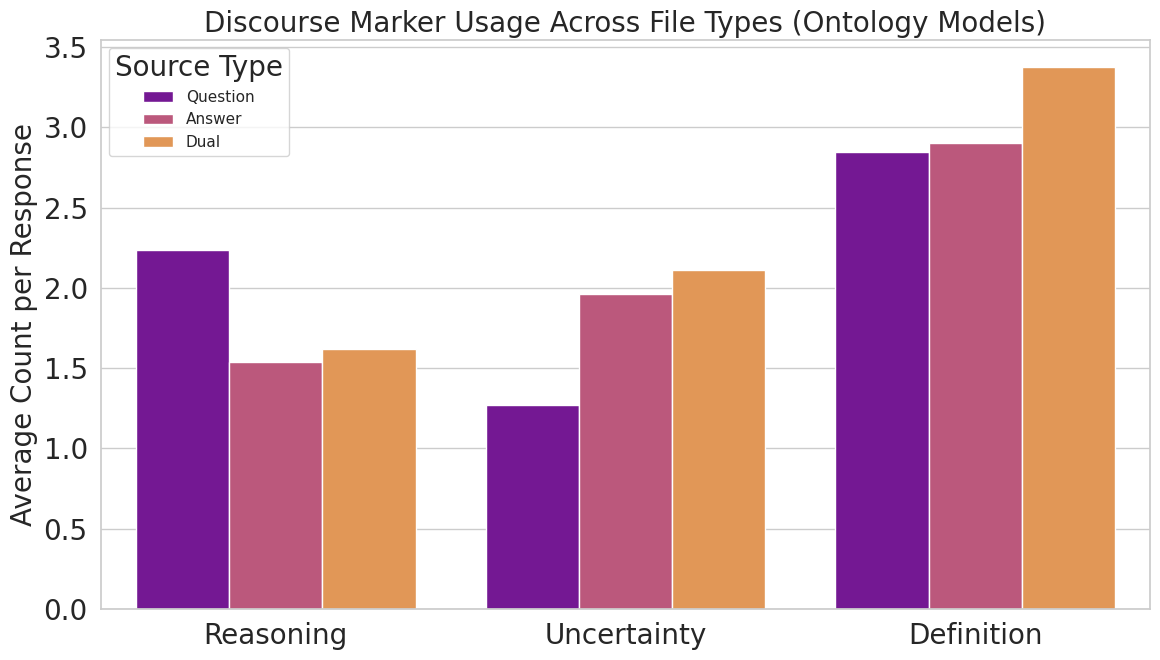

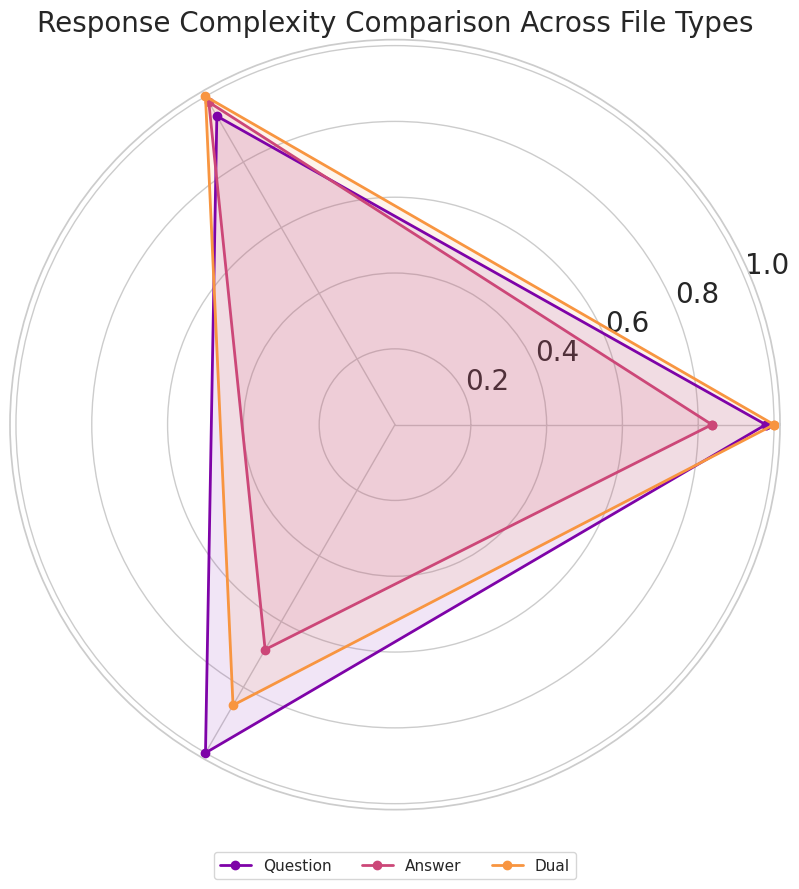

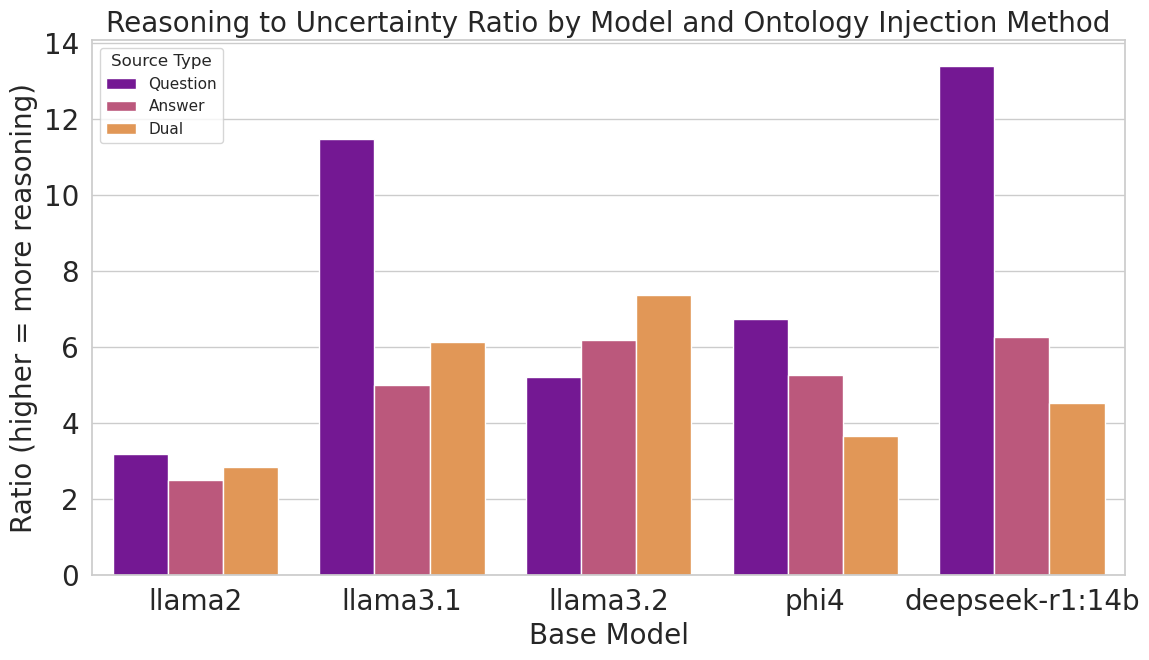

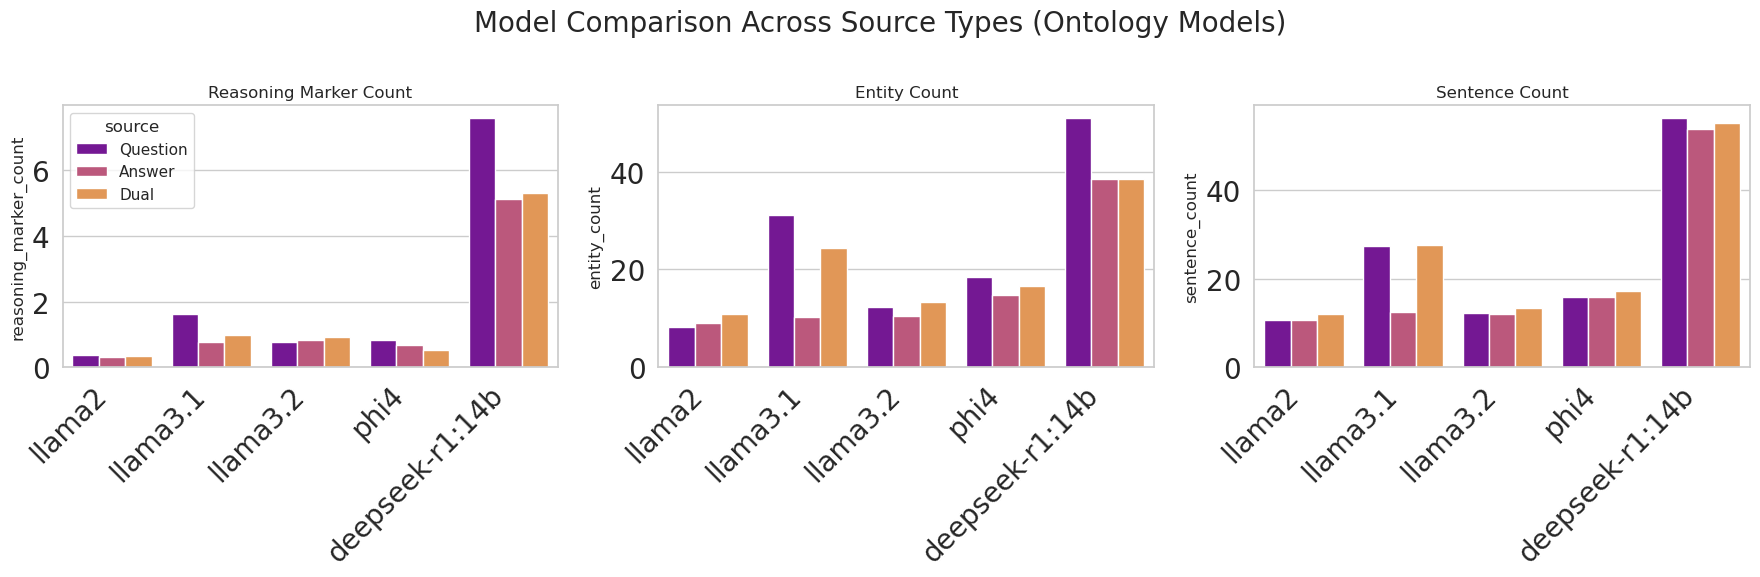

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualize_across_files(question_file, answer_file, dual_file, output_prefix='cross_file'):
    # Set the aesthetic style
    sns.set_theme(style="whitegrid")
    
    plt.rcParams.update({
    'font.size': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20
    })

    
    # Use correct plasma palette
    file_count = 3  # Question, Answer, Dual
    plasma_colors = sns.color_palette("plasma", n_colors=file_count)
    
    # Load the data from each file
    df_question = pd.read_csv(question_file)
    df_answer = pd.read_csv(answer_file)
    df_dual = pd.read_csv(dual_file)
    
    # Add source column to each dataframe
    df_question['source'] = 'Question'
    df_answer['source'] = 'Answer'
    df_dual['source'] = 'Dual'
    
    # Filter only ontology responses
    df_question = df_question[df_question['response_type'] == 'onto']
    df_answer = df_answer[df_answer['response_type'] == 'onto']
    df_dual = df_dual[df_dual['response_type'] == 'onto']
    
    # Combine the dataframes
    df_combined = pd.concat([df_question, df_answer, df_dual])
    
    # Define the specific model order and source order
    model_order = ['llama2', 'llama3.1', 'llama3.2', 'phi4', 'deepseek-r1:14b']
    source_order = ['Question', 'Answer', 'Dual']
    
    # Ensure ordering is consistent
    df_combined['base_model'] = pd.Categorical(df_combined['base_model'], categories=model_order, ordered=True)
    df_combined['source'] = pd.Categorical(df_combined['source'], categories=source_order, ordered=True)
    
    # 1. Discourse marker bar chart
    plt.figure(figsize=(12, 7))
    marker_data = df_combined.groupby('source')[
        ['reasoning_marker_count', 'uncertainty_marker_count', 'definition_marker_count']
    ].mean().reset_index()
    
    marker_data_melted = pd.melt(
        marker_data,
        id_vars=['source'],
        value_vars=['reasoning_marker_count', 'uncertainty_marker_count', 'definition_marker_count'],
        var_name='Marker Type',
        value_name='Average Count'
    )
    
    ax = sns.barplot(
        x='Marker Type',
        y='Average Count',
        hue='source',
        data=marker_data_melted,
        palette=plasma_colors,
        hue_order=source_order
    )
    ax.set_xticklabels([x.get_text().replace('_marker_count', '').title() for x in ax.get_xticklabels()])
    plt.title('Discourse Marker Usage Across File Types (Ontology Models)', fontsize=20)
    plt.ylabel('Average Count per Response', fontsize=20)
    plt.xlabel('', fontsize=20)
    plt.legend(title='Source Type', title_fontsize=20)
    plt.tight_layout()
    plt.savefig(f'{output_prefix}_discourse_markers.png', dpi=300)
    
    # 2. Radar chart (without spoke labels)
    complexity_data = df_combined.groupby('source')[
        ['sentence_count', 'avg_sentence_length', 'entity_count']
    ].mean()
    
    complexity_max = complexity_data.max()
    complexity_norm = complexity_data / complexity_max
    
    plt.figure(figsize=(10, 10))
    ax = plt.subplot(111, polar=True)
    
    categories = ['Sentence Count', 'Entity Count', 'Avg Sentence Length']
    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
    angles_plot = np.append(angles, angles[0])  # Close the loop
    
    for i, source in enumerate(source_order):
        if source in complexity_norm.index:
            values = complexity_norm.loc[source].values.tolist()
            values.append(values[0])  # Close the loop
            ax.plot(angles_plot, values, 'o-', linewidth=2, label=source, color=plasma_colors[i])
            ax.fill(angles_plot, values, alpha=0.1, color=plasma_colors[i])
    
    ax.set_xticks(angles)
    ax.set_xticklabels([])  # <--- Leave labels blank so you can add them manually
    
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=3)
    plt.title('Response Complexity Comparison Across File Types', fontsize=20)
    plt.savefig(f'{output_prefix}_complexity_radar.png', bbox_inches='tight', dpi=300)
    
    # 3. Reasoning to uncertainty ratio
    plt.figure(figsize=(12, 7))
    df_combined['reasoning_to_uncertainty'] = df_combined['reasoning_marker_count'] / (df_combined['uncertainty_marker_count'] + 0.1)
    
    model_source_metrics = df_combined.groupby(['base_model', 'source'])['reasoning_to_uncertainty'].mean().reset_index()
    
    sns.barplot(
        x='base_model',
        y='reasoning_to_uncertainty',
        hue='source',
        data=model_source_metrics,
        palette=plasma_colors,
        order=model_order,
        hue_order=source_order
    )
    
    plt.title('Reasoning to Uncertainty Ratio by Model and Ontology Injection Method', fontsize=20)
    plt.ylabel('Ratio (higher = more reasoning)', fontsize=20)
    plt.xlabel('Base Model', fontsize=20)
    plt.legend(title='Source Type')
    plt.tight_layout()
    plt.savefig(f'{output_prefix}_reasoning_ratio.png', dpi=300)
    
    # 4. Comparative metrics across models and sources
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
    model_metrics = df_combined.groupby(['base_model', 'source']).agg({
        'reasoning_marker_count': 'mean',
        'entity_count': 'mean',
        'sentence_count': 'mean'
    }).reset_index()
    
    metrics = ['reasoning_marker_count', 'entity_count', 'sentence_count']
    for i, metric in enumerate(metrics):
        sns.barplot(
            x='base_model',
            y=metric,
            hue='source',
            data=model_metrics,
            palette=plasma_colors,
            order=model_order,
            hue_order=source_order,
            ax=axes[i]
        )
        axes[i].set_title(metric.replace('_', ' ').title())
        axes[i].set_xlabel('')
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
        if i > 0:
            axes[i].get_legend().remove()
    
    plt.suptitle('Model Comparison Across Source Types (Ontology Models)', fontsize=20)
    plt.tight_layout()
    plt.savefig(f'{output_prefix}_metrics_comparison.png', dpi=300)
    
    print("Cross-file comparisons created successfully!")

if __name__ == "__main__":
    question_file = '/home/matt/Proj/Hermeticav2/scripts/semantic_analysis_results_Question.csv'
    answer_file = '/home/matt/Proj/Hermeticav2/scripts/semantic_analysis_results.csv'
    dual_file = '/home/matt/Proj/Hermeticav2/scripts/semantic_analysis_results_Dual.csv'
    
    visualize_across_files(question_file, answer_file, dual_file)
